In [1]:
import numpy as np
import matplotlib.pyplot as plt
import inspect,copy
from scipy import stats
import itertools

In [2]:
data_digits = np.load(r"math4ai_capstone/starter_pack/data/digits_data.npz")
digits_split_indices = np.load(r"math4ai_capstone/starter_pack/data/digits_split_indices.npz")
data_linear = np.load(r"math4ai_capstone/starter_pack/data/linear_gaussian.npz")
data_moons = np.load(r"math4ai_capstone/starter_pack/data/moons.npz")

In [3]:
data_digits.files

['X', 'y']

In [4]:
data_linear.files

['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']

In [5]:
digits_split_indices.files

['train_idx', 'val_idx', 'test_idx']

In [6]:
data_moons.files

['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']

In [7]:
X_d_train = data_digits["X"][digits_split_indices["train_idx"]]
y_d_train = data_digits["y"][digits_split_indices["train_idx"]]
X_d_test = data_digits["X"][digits_split_indices["test_idx"]]
y_d_test = data_digits["y"][digits_split_indices["test_idx"]]
X_d_val = data_digits["X"][digits_split_indices["val_idx"]]
y_d_val = data_digits["y"][digits_split_indices["val_idx"]]

In [8]:
X_l_train=data_linear['X_train']
y_l_train= data_linear['y_train']
X_l_val=data_linear['X_val']
y_l_val= data_linear['y_val']
X_l_test=data_linear['X_test'] 
y_l_test=data_linear['y_test']

In [9]:
X_m_train=data_moons['X_train']
y_m_train= data_moons['y_train']
X_m_val=data_moons['X_val']
y_m_val= data_moons['y_val']
X_m_test=data_moons['X_test'] 
y_m_test=data_moons['y_test']

In [10]:
data = [(X_d_train,y_d_train,X_d_val,y_d_val),(X_l_train,y_l_train,X_l_val,y_l_val),(X_m_train,y_m_train,X_m_val,y_m_val)]
test_data = [(X_d_test,y_d_test),(X_l_test,y_l_test),(X_m_test,y_m_test)]
data_name = ["Digits","Linear gaussian","Moons"]

In [11]:
for i,(X_tr,y_tr,X_va,y_va) in enumerate(data):
    print(f"Data set name {data_name[i]}")
    print(f"X_train shape {X_tr.shape}")
    print(f"Y_train shape {y_tr.shape}")
    
    print(f"X_validation shape {X_va.shape}")
    print(f"Y_val shape {y_va.shape}")
    X_t,y_t = test_data[i]
    print(f"X_test shape {X_t.shape}")
    print(f"Y_test shape {y_t.shape}") 
    print()

Data set name Digits
X_train shape (1074, 64)
Y_train shape (1074,)
X_validation shape (355, 64)
Y_val shape (355,)
X_test shape (368, 64)
Y_test shape (368,)

Data set name Linear gaussian
X_train shape (240, 2)
Y_train shape (240,)
X_validation shape (80, 2)
Y_val shape (80,)
X_test shape (80, 2)
Y_test shape (80,)

Data set name Moons
X_train shape (240, 2)
Y_train shape (240,)
X_validation shape (80, 2)
Y_val shape (80,)
X_test shape (80, 2)
Y_test shape (80,)



In [12]:
def accuracy(y_pred,y_test):
    return np.mean(y_pred==y_test)


def softmax(X):
    Z = X -  np.max(X, axis=1, keepdims=True)
    S = np.exp(Z)
    return S/np.sum(S,axis=1,keepdims=True)
    
def one_hot_encoder(y,labels):
    Y = np.zeros((y.shape[0],labels.size))
    for i, val in enumerate(y):
        idx, = np.where(labels==val)
        Y[i,idx] = 1
    return Y

def plot_hist(y,idxs,axs):
    bins = np.arange(y.min()-0.5, y.max()+1.5, 1)
    axs[0].set_ylabel("Count")
    axs[0].set_xlabel("Labels")
    axs[0].set_xticks(np.unique(y))
    axs[0].set_title("Orjinal Data")
    axs[0].hist(y,bins=bins,rwidth=0.8,color="orange")

    axs[1].set_ylabel("Count")
    axs[1].set_xlabel("Labels")
    axs[1].set_title("Bias edilmiş data")
    axs[1].set_xticks(np.unique(y))
    axs[1].hist(y[idxs],bins=bins,rwidth=0.8,color="orange")

def make_bias(y,cls):
    idx = np.where(y==cls)[0]
    r_idx = np.random.choice(idx,int(np.floor(0.95*len(idx))),replace=False)
    m = np.ones_like(y,dtype=bool)
    m[r_idx]=False
    return m


In [13]:
class Validation():
    def __init__(self,estimator,X_train,y_train,X_val,y_val,X_test,y_test,params = {},epochs = 200,cv=5):
        self.estimator=estimator
        self.cv = cv
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.results = []
        self.models = []
        self.params = params
        self.epochs = epochs
        
        
    def fit(self):
        self.select_best_params_and_epochs()
        for i in range(self.cv):
            np.random.seed(i)
            model = self.estimator(**copy.deepcopy(self.params),epochs=self.best_epoch)
            model.fit(self.X_train,self.y_train)
            self.models.append(model)
            y_pred = model.predict(self.X_test)
            self.results.append(accuracy(y_pred,self.y_test))
        return max(self.results),self.models[np.argmax(self.results)]

    def select_best_params_and_epochs(self):
        loss = np.inf
        model = self.estimator(**copy.deepcopy(self.params))
        model.labels = np.unique(self.y_train)
        model.n,model.m = self.X_train.shape
        model._initialize_weights(self.X_train,self.y_train)
        
        Y_train = one_hot_encoder(self.y_train,model.labels)
        Y_val = one_hot_encoder(self.y_val,model.labels)
        
        
        for j in range(self.epochs):
            A = model._forward(self.X_train)
            y_train_pred=model._predict(self.X_train)
            model.loss.append(model._calculate_loss(Y_train,y_train_pred))

            y_val_pred = model._predict(self.X_val)
            v_loss = model._calculate_loss(Y_val,y_val_pred)
            
            if v_loss < loss:
                self.best_epoch = j
                loss = v_loss
                
            model.back_propagation(self.X_train,Y_train)
            model._optimize()
        
    
    def report(self,ax=None):
        loss = [m.loss[-1] for m in self.models]
        l_m = np.mean(loss)
        a_m = np.mean(self.results)
        l_s = np.std(loss,ddof=1)
        a_s = np.std(self.results,ddof=1)
        
        critic_value = stats.t.ppf(0.975, df=self.cv-1)
        confidence_interval_for_loss = (l_m -critic_value*l_s/np.sqrt(self.cv),l_m +critic_value*l_s/np.sqrt(self.cv))
        confidence_interval_for_accuracy = (a_m -critic_value*a_s/np.sqrt(self.cv),a_m +critic_value*a_s/np.sqrt(self.cv))
        low_a, high_a = confidence_interval_for_accuracy
        low_l, high_l = confidence_interval_for_loss
        
        print(f"Accuracy mean:{a_m:.5f}")
        print(f"Loss mean for {self.cv} models:{l_m:.5f}")
        print(f"95 % Confidence Interval for Accuracy mean:({low_a:.5f},{high_a:.5f})")
        print(f"95 % Confidence Interval for Loss mean:({low_l:.5f},{high_l:.5f})")
        self.accuracy_per_class(self.X_val,self.y_val,ax)


    @staticmethod
    def test_model(model,X_train,y_train,X_val,y_val,X_test,y_test,epochs=200,axes=np.zeros((1,2))):
        if not np.all(axes):
            fig,axes = plt.subplots(1,2,figsize=(8,6))
        
        model.labels = np.unique(y_train)
        model.n,model.m = X_train.shape
        model._initialize_weights(X_train,y_train)
        train_loss=[]
        val_loss = []
        test_loss = []

        train_acc=[]
        val_acc = []
        test_acc = []
        
        labels = np.unique(y_train)
        Y_train = one_hot_encoder(y_train,labels)
        Y_val = one_hot_encoder(y_val,labels)
        Y_test = one_hot_encoder(y_test,labels)
        for j in range(epochs):
            
            A = model._forward(X_train)
            y_train_pred = model._predict(X_train) 
            train_loss.append(model._calculate_loss(Y_train,y_train_pred))
            train_acc.append(accuracy(model.predict(X_train),y_train))
            
            y_val_pred = model._predict(X_val)
            val_loss.append(model._calculate_loss(Y_val,y_val_pred))
            val_acc.append(accuracy(model.predict(X_val),y_val))
            
            y_test_pred = model._predict(X_test)
            test_loss.append(model._calculate_loss(Y_test,y_test_pred))
            test_acc.append(accuracy(model.predict(X_test),y_test))
            
            model.back_propagation(X_train,Y_train)
            model._optimize()
        
        arr = np.hstack([train_loss,val_loss])
    
        # plt.ylim(0,np.quantile(arr,0.95)*1.1)
        # plt.yticks(np.linspace(arr.min(),np.quantile(arr,0.95),10))
        acc_train = accuracy(model.predict(X_train),y_train)
        acc_val = accuracy(model.predict(X_val),y_val)
        acc_test=accuracy(model.predict(X_test),y_test)
        
        text = f"Train Accuracy:{acc_train:.4f}\nValidation Accuracy:{acc_val:.4f}\nTest Accuracy:{acc_test:.4f}\n"
        axes[0].set_title(f"Loss {model.__class__.__name__}")
        axes[0].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axes[0].transAxes,bbox=dict(facecolor='white', alpha=0.7))
        axes[0].plot(range(len(train_loss)),train_loss,label="Train Loss")
        axes[0].plot(range(len(val_loss)),val_loss,label="Validation Loss")
        axes[0].plot(range(len(test_loss)),test_loss,label="Test Loss")
        axes[0].legend()
        axes[0].grid()

       
        axes[1].set_title(f"Accuracy {model.__class__.__name__}")
        axes[1].plot(range(len(train_acc)),train_acc,label="Train Accuracy")
        axes[1].plot(range(len(val_acc)),val_acc,label="Validation Accuracy")
        axes[1].plot(range(len(test_acc)),test_acc,label="Test Accuracy")
        axes[1].set_yticks(np.linspace(0,1,11))
        axes[1].legend()
        axes[1].grid()
        
        
    def accuracy_per_class(self,X,y,ax=None):
        y_pred = self.models[np.argmax(self.results)].predict(X)
        result = y_pred==y
        labels = np.unique(y)
        acc_class = []
        acc = accuracy(y_pred,y)
        for l in labels:
            idx = y==l
            ac = result[idx].sum()/idx.sum()
            acc_class.append(ac)
        if ax is None:
            fig, ax = plt.subplots(1,1,figsize=(8,6))
        bars = ax.bar(labels, acc_class, color="darkorange", edgecolor="k")
        
        for bar, prec in zip(bars, acc_class):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f"{prec:.2f}",
                    ha="center", fontsize=8)
        
        ax.set_title(f"{self.estimator.__name__} Per-Class Accuracy")
        ax.set_xlabel("Class")
        ax.set_ylabel("Accuracy")
        ax.set_xticks(labels)
        ax.set_ylim(0, 1.1)
        ax.axhline(y=acc, color="red", linestyle="--",
                   label=f"Overall Vaildation Accuracy: {acc:.4f}")
        ax.legend()
        
    
        

## Softmax Classification

### Model
$$
X \in \mathbb{R}^{n \times m}, \quad
W \in \mathbb{R}^{K \times m}, \quad
b \in \mathbb{R}^{1 \times K}
$$

---

### Forward Pass
$$
Z = X W^T + b
$$

$$
A = \text{softmax}(Z), \quad
A_{ik} = \frac{e^{Z_{ik}}}{\sum_{j=1}^{K} e^{Z_{ij}}}
$$

---

### Loss Function
$$
L = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} Y_{ik} \log(A_{ik})
+ \frac{\lambda}{2} \|W\|^2
$$

---

### Gradients
$$
\frac{\partial L}{\partial Z} = \frac{A - Y}{n}
$$

$$
\frac{\partial L}{\partial W} = \left(\frac{A - Y}{n}\right)^T X + \lambda W
$$

$$
\frac{\partial L}{\partial b} = \sum_{i=1}^{n} \frac{A - Y}{n}
$$

---

### Update Rule
$$
W := W - \eta \frac{\partial L}{\partial W}
$$

$$
b := b - \eta \frac{\partial L}{\partial b}
$$

---

### Prediction
$$
\hat{y} = \arg\max(A, \text{axis}=1)
$$

---

### Gradient Check
$$
\frac{\partial L}{\partial W_{ij}} \approx 
\frac{L(W_{ij} + \epsilon) - L(W_{ij} - \epsilon)}{2\epsilon}
$$

$$
\text{diff} =
\frac{
\|\nabla_{analytic} - \nabla_{numerical}\|
}{
\|\nabla_{analytic}\| + \|\nabla_{numerical}\|
}
$$

In [14]:
class SoftMaxClassification:
    def __init__(self,penalty = "l2",lamda = 1e-4,learning_rate = 0.05,epochs = 200,batch_size=64,optimizer="sgd",init_weights=True):
        self.penalty = penalty
        self.lamda = lamda
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.loss = []
        self.cache = {}
        self.optimizer=optimizer
        self.init_weights = init_weights
    
    def fit(self,X_train,y_train):
        self.labels = np.unique(y_train)
        self.n,self.m = X_train.shape
        
        self.loss = []
        if self.init_weights:
            self._initialize_weights(X_train,y_train)
        
        Y = one_hot_encoder(y_train,self.labels) 
        idxs = np.arange(self.n)
        
        for _ in range(self.epochs):
            np.random.shuffle(idxs)
            X_shuffled = X_train[idxs]
            Y_shuffled = Y[idxs]
            for j in range(0,self.n,self.batch_size):
                X_batch = X_shuffled[j:j+self.batch_size]
                Y_batch = Y_shuffled[j:j+self.batch_size]
                self._forward(X_batch)
                self.back_propagation(X_batch,Y_batch)
                self._optimize()
                
            A = self._forward(X_train)   
            L =self._calculate_loss(Y,A)
            self.loss.append(L)
            
    def _initialize_weights(self,X_train,y_train):
        self.W = np.random.randn(len(self.labels),self.m)*np.sqrt(1/self.m) 
        self.b = np.zeros((1,len(self.labels)))
    
    def _l2(self):
        return 0.5 * self.lamda * np.sum(np.power(self.W,2))

    def _forward(self,X_val):
        Z = X_val @ self.W.T + self.b
        self.cache["A"] = softmax(Z)
        return self.cache["A"]
         
    def back_propagation(self,X,Y):
        dLdZ = (self.cache.get("A",0) - Y)/X.shape[0]
        dZdW = X
        reg_term = self.lamda * self.W
        self.cache["dW"] =  dLdZ.T @ X+ reg_term
        self.cache["db"] = np.sum(dLdZ, axis=0, keepdims=True)
        
    def _optimize(self):  
        self.W -= self.learning_rate * self.cache["dW"]
        self.b -= self.learning_rate * self.cache["db"]
        
    def _predict(self,X_val):
        Z = X_val @ self.W.T + self.b
        return softmax(Z)
        
    def predict(self,X_val):
        A = self._predict(X_val)
        return self.labels[np.argmax(A,axis=1)]

    def _calculate_loss(self,Y,y_predict):
        return -np.mean(np.sum(Y*np.log(y_predict + 1e-9),axis=1)) + self._l2()
    
    def plot_decision_boundary(self,X,y,ax=None):
        if ax is None:
            fig, ax = plt.subplots(1,1,figsize=(8,6))
        if X.shape[1] > 2:
            raise ValueError("Only for 2 dimension")
            
        w_diff = self.W[0] - self.W[1]
        b_diff = self.b[0,0] - self.b[0,1]
        X1 = np.sort(X[:,1])
        X0 = -(X1 * w_diff[1] + b_diff)/w_diff[0]
         
        ax.set_title(f"{self.__class__.__name__} Decision Boundary\nOptimizer:{self.optimizer.capitalize()};\nLearning rate:{self.learning_rate};Loss:{self.loss[-1]:.4f};Iteration:{self.epochs}")
        ax.set_ylabel("X1")
        ax.set_xlabel("X0")
        ax.scatter(X[:,0],X[:,1],c=y)
        ax.plot(X0,X1,color="red")
     


    @classmethod
    def gradient_check(cls,X,y,params = {},epsilon=1e-7):
        model = cls(**copy.deepcopy(params))
        model.fit(X,y)
        
        Y = one_hot_encoder(y,np.unique(y))
        
        model._forward(X)
        model.back_propagation(X, Y)    
        
        grad_analytic = np.copy(model.cache["dW"])
        grad_num = np.zeros_like(grad_analytic)
        
        for i in range(grad_analytic.shape[0]):
            for j in range(grad_analytic.shape[1]):
                
                model.W[i,j] += epsilon
                y_plus = model._forward(X)
                L1 = model._calculate_loss(Y,y_plus)
                model.W[i,j] -= 2*epsilon
                
                y_minus = model._forward(X)
                L2 = model._calculate_loss(Y,y_minus)
                model.W[i,j] += epsilon
                
                grad_num[i,j] = (L1 - L2)/(2*epsilon)
                
        diff = np.linalg.norm(grad_analytic - grad_num) / (np.linalg.norm(grad_analytic) + np.linalg.norm(grad_num))
        print(f"Gradient check difference for {cls.__name__}:", diff)
            
        return diff
   
    
    def plot_loss(self,ax=None):
        if ax is None:
            fig, ax = plt.subplots(1,1,figsize=(8,6))
        
        ax.set_title(f"{self.__class__.__name__}\nOptimizer:{self.optimizer.capitalize()};\nLearning rate:{self.learning_rate}")
        ax.plot(range(len(self.loss)),self.loss)
        ax.set_ylabel("Training Loss")
        ax.set_yticks(np.linspace(min(self.loss), max(self.loss), 10))
        ax.set_xlabel("Epochs")
        ax.grid()

## Neural Network (1 Hidden Layer)

### Model Structure
$$
X \in \mathbb{R}^{n \times m}
$$

$$
W^{[1]} \in \mathbb{R}^{h \times m}, \quad b^{[1]} \in \mathbb{R}^{1 \times h}
$$

$$
W^{[2]} \in \mathbb{R}^{K \times h}, \quad b^{[2]} \in \mathbb{R}^{1 \times K}
$$

---

### Forward Pass

#### Hidden Layer
$$
Z^{[1]} = X W^{[1]^T} + b^{[1]}
$$

$$
A^{[1]} = \tanh(Z^{[1]})
$$

---

#### Output Layer
$$
Z^{[2]} = A^{[1]} W^{[2]^T} + b^{[2]}
$$

$$
A^{[2]} = \text{softmax}(Z^{[2]})
$$

---

### Softmax
$$
A^{[2]}_{ik} = \frac{e^{Z^{[2]}_{ik}}}{\sum_{j=1}^{K} e^{Z^{[2]}_{ij}}}
$$

---

### Loss Function
$$
L = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} Y_{ik} \log(A^{[2]}_{ik})
+ \frac{\lambda}{2} \left( \|W^{[1]}\|^2 + \|W^{[2]}\|^2 \right)
$$

---

### Backpropagation

#### Output Layer Gradient
$$
\frac{\partial L}{\partial Z^{[2]}} = \frac{A^{[2]} - Y}{n}
$$

$$
\frac{\partial L}{\partial W^{[2]}} =
\left(\frac{A^{[2]} - Y}{n}\right)^T A^{[1]} + \lambda W^{[2]}
$$

$$
\frac{\partial L}{\partial b^{[2]}} =
\sum_{i=1}^{n} \frac{A^{[2]} - Y}{n}
$$

---

#### Hidden Layer Gradient
$$
\frac{\partial L}{\partial A^{[1]}} =
\frac{\partial L}{\partial Z^{[2]}} W^{[2]}
$$

$$
\frac{\partial L}{\partial Z^{[1]}} =
\frac{\partial L}{\partial A^{[1]}} \cdot (1 - A^{[1]^2})
$$

$$
\frac{\partial L}{\partial W^{[1]}} =
\left(\frac{\partial L}{\partial Z^{[1]}}\right)^T X + \lambda W^{[1]}
$$

$$
\frac{\partial L}{\partial b^{[1]}} =
\sum \frac{\partial L}{\partial Z^{[1]}}
$$

---

### Optimization

#### SGD
$$
W := W - \eta \frac{\partial L}{\partial W}
$$

$$
b := b - \eta \frac{\partial L}{\partial b}
$$

---

#### Momentum
$$
v = \beta v + (1 - \beta)\nabla W
$$

$$
W := W - \eta v
$$

---

#### Adam
$$
m = \beta_1 m + (1 - \beta_1) g
$$

$$
v = \beta_2 v + (1 - \beta_2) g^2
$$

$$
\hat{m} = \frac{m}{1 - \beta_1^t}, \quad
\hat{v} = \frac{v}{1 - \beta_2^t}
$$

$$
W := W - \eta \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}
$$

---

### Prediction
$$
\hat{y} = \arg\max(A^{[2]}, \text{axis}=1)
$$

---

### Gradient Check
$$
\frac{\partial L}{\partial W} \approx
\frac{L(W + \epsilon) - L(W - \epsilon)}{2\epsilon}
$$

$$
\text{diff} =
\frac{
\|\nabla_{analytic} - \nabla_{numerical}\|
}{
\|\nabla_{analytic}\| + \|\nabla_{numerical}\|
}
$$

In [15]:

class NeuralNetwork():
    def __init__(self,size=[32],lamda = 1e-4,batch_size=64,learning_rate = None, optimizer="sgd",epochs = 200,activation_functions = (np.tanh,softmax),init_weights=True):
        self.size = size
        self.batch_size = batch_size
        if not learning_rate:
            self.learning_rate = 0.001 if optimizer=="adam" else 0.05
        else:
            self.learning_rate = learning_rate
        self.cache = {}
        self.optimizer=optimizer
        self.lamda = lamda
        self.epochs = epochs
        self.loss=[]
        self.activation_functions = activation_functions
        self.init_weights = init_weights
    
    def fit(self,X_train,y_train):
        self.n,self.m = X_train.shape
        self.labels = np.unique(y_train)
        
        if self.init_weights:
            self._initialize_weights(X_train,y_train) 
        Y = one_hot_encoder(y_train,self.labels)
        
        idxs = np.arange(self.n)
        for e in range(self.epochs):
            np.random.shuffle(idxs)
            X_shuffled = X_train[idxs]
            Y_shuffled = Y[idxs]
            for j in range(0,self.n,self.batch_size):
                X_batch = X_shuffled[j:j+self.batch_size]
                Y_batch = Y_shuffled[j:j+self.batch_size]
                
                self._forward(X_batch)
                self.back_propagation(X_batch,Y_batch)
                self._optimize()
                


            y_pred = self._predict(X_train)
            L = self._calculate_loss(Y,y_pred)
            self.loss.append(L)

            
    def _initialize_weights(self,X_train,y_train):
        
        size = [self.m] + self.size + [len(self.labels)]
        
        self.W = [np.random.randn(size[i+1],size[i])*np.sqrt(1/size[i]) for i in range(len(size)-1)]
        self.b = [np.zeros((1,size[i+1])) for i in range(len(size)-1)]
    
    def _forward(self,X_batch):
        A = X_batch
        for i,(w,b) in enumerate(zip(self.W,self.b)):
            activation = self.activation_functions[i]
            A = activation(A @ w.T + b)
            self.cache[f"A{i}"] = A

    def _calculate_loss(self,Y,y_predict):
        return -np.mean(np.sum(Y*np.log(y_predict + 1e-9),axis=1)) + self._l2()
    
    def _optimize(self):
        if self.optimizer=="sgd":
            self.sgd()
        elif self.optimizer=="adam":
            self.adam()
        else:
            self.momentum()
        
    def back_propagation(self,X,Y):
        dLdZ= (self.cache["A1"] - Y)/Y.shape[0]
        dZdW2 = self.cache["A0"]
        self.cache["dW2"] = dLdZ.T @ dZdW2 + self.lamda*self.W[1]
        self.cache["db2"] = np.sum(dLdZ, axis=0, keepdims=True)
        
        dLdH =  dLdZ @ self.W[1]
        dLdK = dLdH * (1 - self.cache["A0"]**2)
        self.cache["dW1"] = dLdK.T @ X + self.lamda * self.W[0]
        self.cache["db1"] = np.sum(dLdK, axis=0, keepdims=True)
        
        # print("softmax",self.cache["softmax"].shape)
        # print("dLdZ",dLdZ.shape)
        # print("dZdW2",dZdW2.shape)
        # print("dLdH",dLdH.shape)
        # print("dLdK",dLdK.shape)

    def _l2(self):
        return 0.5 * self.lamda * np.sum([np.sum(np.power(w,2)) for w in self.W]) 
    
    def sgd(self):
        for i in range(len(self.W)):
            self.W[i]-= self.learning_rate * self.cache[f"dW{i+1}"]
            self.b[i]-= self.learning_rate * self.cache[f"db{i+1}"]

        
      

    def momentum(self,beta = 0.9):
        if not hasattr(self,"v_w"):
            self.v_w = [np.zeros_like(w) for w in self.W]
            self.v_b = [np.zeros_like(b) for b in self.b]
            
        for i in range(len(self.W)):
            self.v_w[i] = beta*self.v_w[i] + (1-beta)*self.cache[f"dW{i+1}"]
            self.v_b[i] = beta*self.v_b[i] + (1-beta)*self.cache[f"db{i+1}"]

            self.W[i] -= self.learning_rate * self.v_w[i]
            self.b[i] -= self.learning_rate * self.v_b[i]
        

    def adam(self,beta_1=0.9,beta_2=0.999, epsilon=1e-8):
        if not hasattr(self, "m_w"):
            self.m_w = [np.zeros_like(w) for w in self.W]
            self.v_w = [np.zeros_like(w) for w in self.W]
            self.m_b = [np.zeros_like(b) for b in self.b]
            self.v_b = [np.zeros_like(b) for b in self.b]
            self.t = 0
        self.t += 1

        for i in range(len(self.W)):
            self.m_w[i] = beta_1 * self.m_w[i] + (1 - beta_1) * self.cache[f"dW{i+1}"]
            self.v_w[i] = beta_2 * self.v_w[i] + (1 - beta_2) * (self.cache[f"dW{i+1}"]**2)
            m_hat = self.m_w[i] / (1 - beta_1**self.t)
            v_hat = self.v_w[i] / (1 - beta_2**self.t)
            self.W[i] -= self.learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
            
            self.m_b[i] = beta_1 * self.m_b[i] + (1 - beta_1) * self.cache[f"db{i+1}"]
            self.v_b[i] = beta_2 * self.v_b[i] + (1 - beta_2) * (self.cache[f"db{i+1}"]**2)
            mb_hat = self.m_b[i] / (1 - beta_1**self.t)
            vb_hat = self.v_b[i] / (1 - beta_2**self.t)
            self.b[i] -= self.learning_rate * mb_hat / (np.sqrt(vb_hat) + epsilon)

    def _predict(self, X):
        A = X
        for i,(w,b) in enumerate(zip(self.W,self.b)):
            A = self.activation_functions[i](A @ w.T + b)
        return A

    @classmethod
    def gradient_check(cls,X,y,params = {},epsilon=1e-7):
        model = cls(**copy.deepcopy(params))
        model.fit(X,y)
        
        Y = one_hot_encoder(y,model.labels)
        model._forward(X)
        model.back_propagation(X, Y)    
        max_diff = 0
        for l in range(len(model.W)):
            grad_analytic = np.copy(model.cache[f"dW{l+1}"])
            grad_num = np.zeros_like(grad_analytic)
            for i in range(grad_analytic.shape[0]):
                for j in range(grad_analytic.shape[1]):
                    model.W[l][i,j] += epsilon
                    y_plus = model._predict(X)
                    L1 = model._calculate_loss(Y,y_plus)
    
                    model.W[l][i,j] -= 2*epsilon
                    y_minus = model._predict(X)
                    L2 = model._calculate_loss(Y,y_minus)
                    model.W[l][i,j] += epsilon
                    grad_num[i,j] = (L1 - L2)/(2*epsilon)
                
            diff = np.linalg.norm(grad_analytic - grad_num) / (np.linalg.norm(grad_analytic) + np.linalg.norm(grad_num))
            max_diff = max(max_diff,diff)
        print(f"Gradient check difference for {cls.__name__}:", max_diff)
        return max_diff
    
    def predict(self, X):
        result = self._predict(X)
        return self.labels[np.argmax(result,axis=1)]
        
    def plot_decision_boundary(self, X, y, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))

        if X.shape[1] > 2:
            from sklearn.decomposition import PCA
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
        else:
            X_2d = X
    
        x0_min, x0_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
        x1_min, x1_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    
        xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 200),
                             np.linspace(x1_min, x1_max, 200))
        if X.shape[1] > 2:
            grid_original = pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
            Z = self.predict(grid_original)
        else:
            Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    
        Z = Z.reshape(xx.shape)
    
        ax.contourf(xx, yy, Z, alpha=0.3)
        ax.contour(xx, yy, Z, colors="red", linewidths=1)
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors="k", linewidths=0.5)
        ax.set_title(f"{self.__class__.__name__}\nDecision Boundary {'(PCA 2D)' if X.shape[1] > 2 else ''} \nOptimizer:{self.optimizer.capitalize()}; Hidden Layer Size:{self.size};\nLearning rate:{self.learning_rate};Epochs:{self.epochs};Loss: {self.loss[-1]:.4f}")
        ax.set_xlabel("PC1" if X.shape[1] > 2 else "X0")
        ax.set_ylabel("PC2" if X.shape[1] > 2 else "X1")
                
    def plot_loss(self,ax=None):
        if ax is None:
            fig, ax = plt.subplots(1,1,figsize=(8,6))
        ax.set_title(f"{self.__class__.__name__}\nOptimizer:{self.optimizer.capitalize()}; Hidden Layer Size:{self.size};\nLearning rate:{self.learning_rate}")
        ax.plot(range(len(self.loss)),self.loss)
        ax.set_ylabel(f"Training Loss")
        ax.set_xlabel("Epochs")
        ax.set_yticks(np.linspace(min(self.loss), max(self.loss), 10))
        ax.grid()
        

## 5.5 Implementation sanity checks
Your report must contain a short subsection titled Implementation Sanity Checks or Verifica-
tion and Debugging Checks. This is a required part of the project.
Include a concise record of at least three checks such as:
- a gradient sanity check on a tiny batch or selected parameter entries,
- evidence that the loss decreases on a tiny subset after a few updates,
- successful overfitting of a very small subset of training examples,
- confirmation that predicted class probabilities sum to one,
- confirmation that training did not silently produce NaNs or infinities.

In [16]:
SoftMaxClassification.gradient_check(X_d_train[:30],y_d_train[:30]),NeuralNetwork.gradient_check(X_d_train[:30],y_d_train[:30])

Gradient check difference for SoftMaxClassification: 3.057243489433586e-08
Gradient check difference for NeuralNetwork: 4.4114862857881623e-08


(np.float64(3.057243489433586e-08), np.float64(4.4114862857881623e-08))

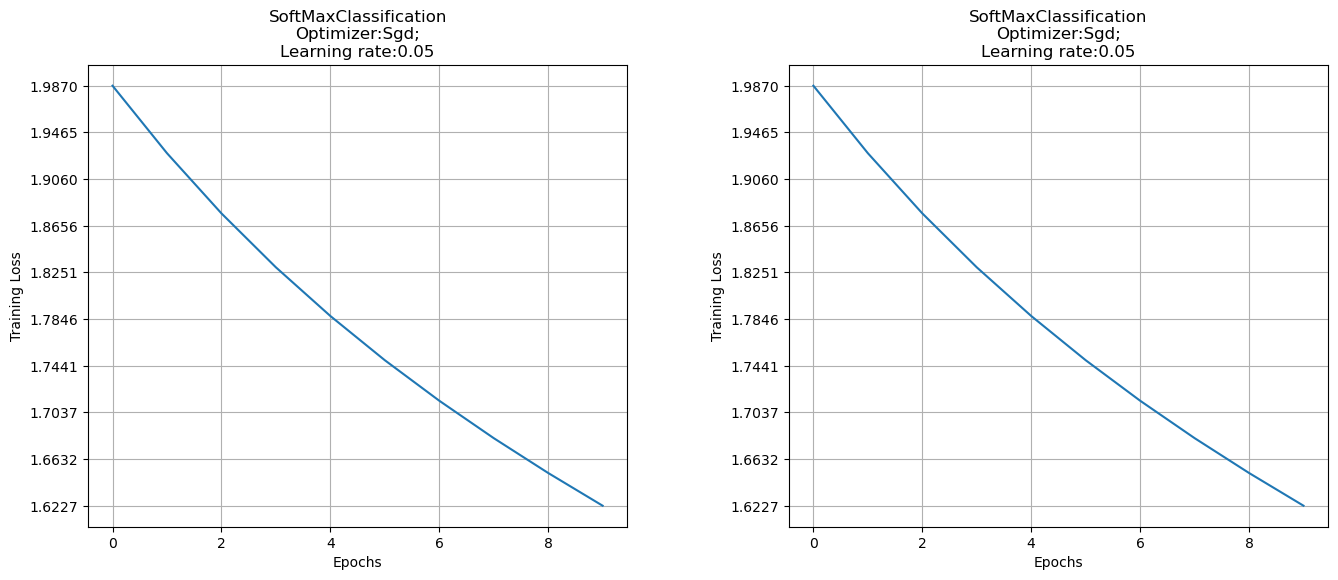

In [17]:
fig, axs = plt.subplots(1, 2,figsize=(16,6),gridspec_kw={"hspace": 0.4, "wspace": 0.3})

ss = SoftMaxClassification(epochs=10)
ss.fit(X_d_train[:10],y_d_train[:10])
ss.plot_loss(ax=axs[0])

nn = NeuralNetwork(epochs=10)
nn.fit(X_d_train[:10],y_d_train[:10])
ss.plot_loss(ax=axs[1])
plt.show()

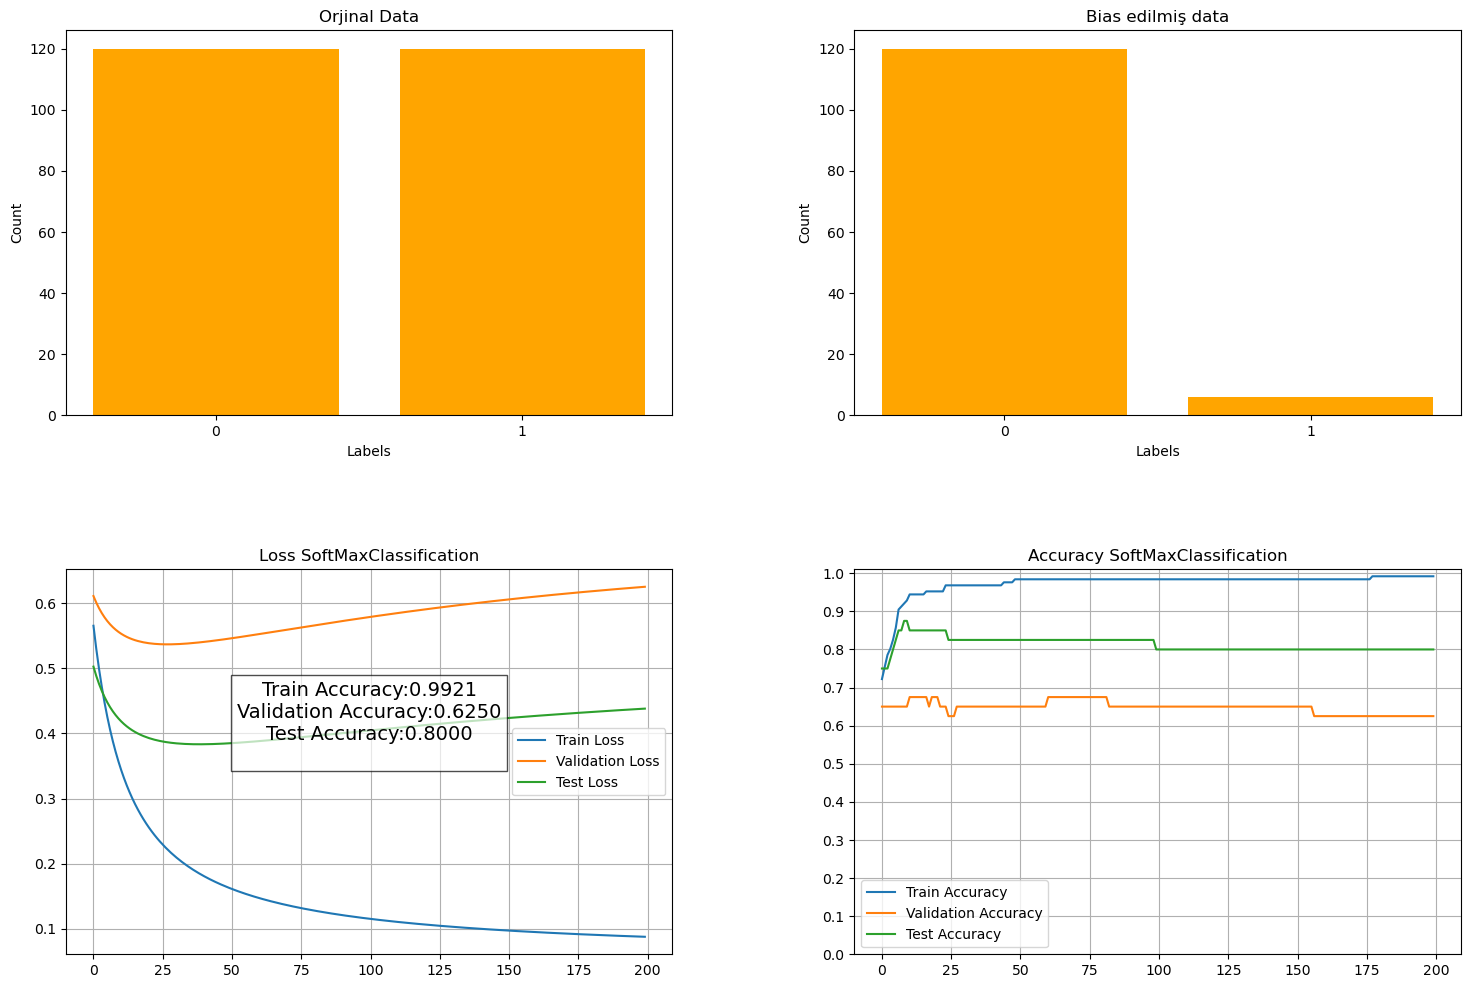

In [18]:
fig, axs = plt.subplots(2, 2,figsize=(18, 12),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
idxs = make_bias(y_l_train,1)
plot_hist(y_l_train,idxs,axs[0])
ss = SoftMaxClassification(learning_rate=0.05,batch_size=32)

t_idxs = np.where((y_l_test==1))
v_idxs = np.where((y_l_val==1))

Validation.test_model(ss,X_l_train[idxs],y_l_train[idxs],X_l_val[v_idxs],y_l_val[v_idxs],X_l_test[t_idxs],y_l_test[t_idxs],axes=axs[1])

In [19]:
s = X_d_test.shape[0]
ss = SoftMaxClassification(learning_rate=0.05,batch_size=32)
ss.fit(X_d_train,y_d_train)
ss._predict(X_d_test[np.random.randint(0,s)]).sum(axis=1),nn._predict(X_d_test[np.random.randint(0,s)]).sum(axis=1)

(array([1.]), array([1.]))

## 7.1 Required core experiments
1. Train and compare both models on the linear Gaussian task. Include decision-boundary plots.
2. Train and compare both models on the moons task. Include decision-boundary plots.
3. Train and compare both models on the fixed digits benchmark using the same preprocessing
and split.

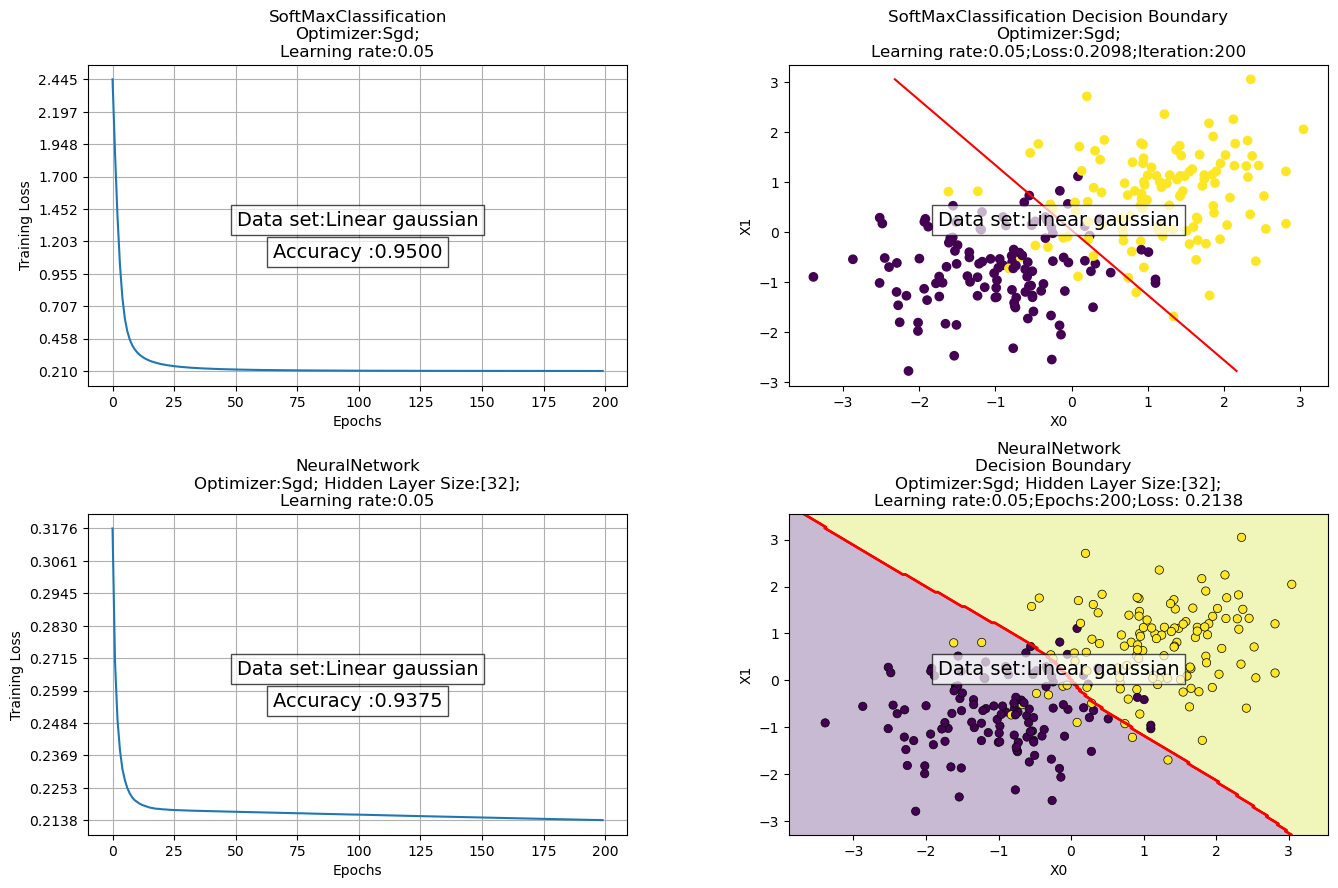

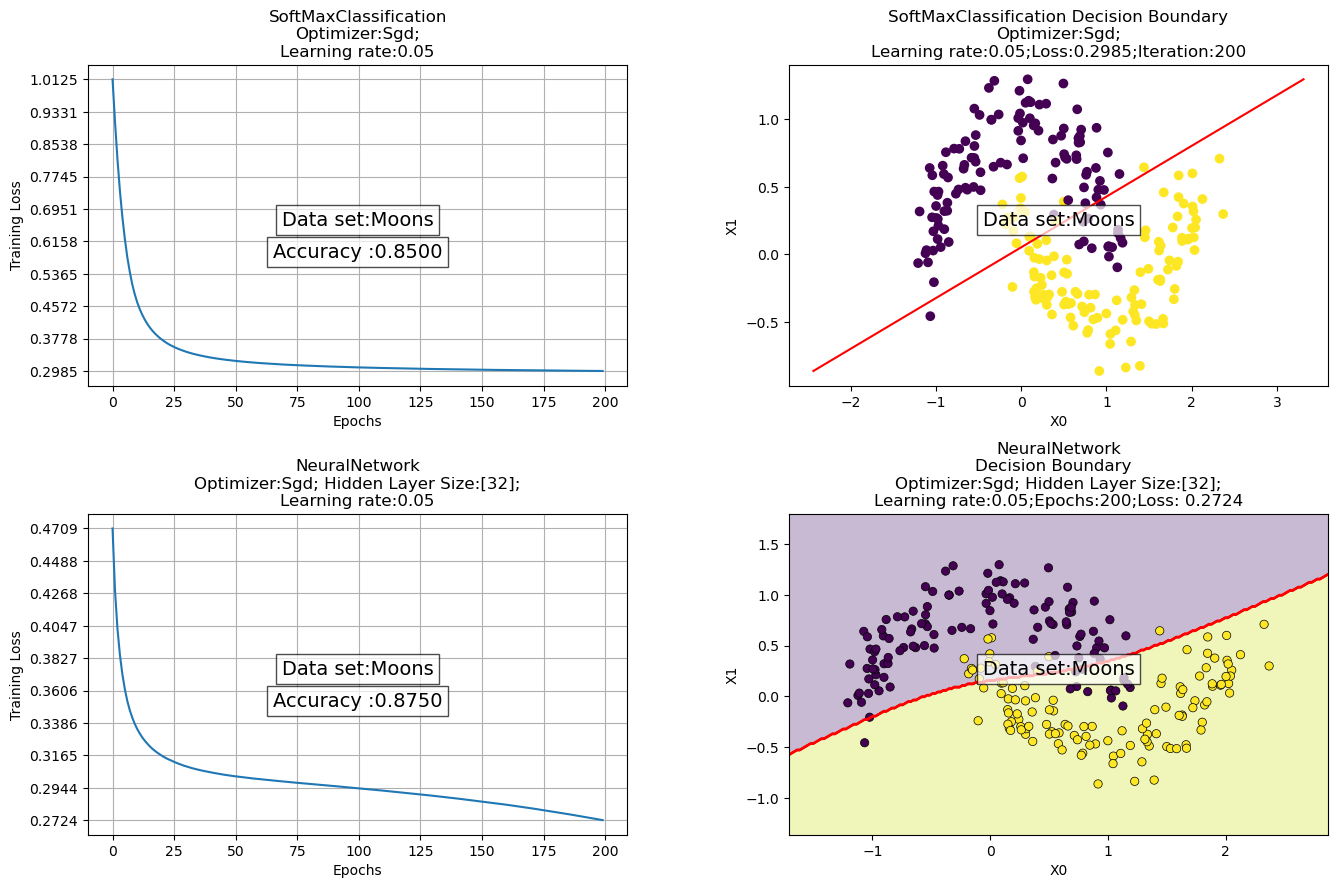

In [20]:
for i,d in enumerate(data[1:],1):
    text = f"Data set:{data_name[i]}"
    fig, axs = plt.subplots(2, 2,figsize=(16,10),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
    for ax in axs.flat:
        ax.text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=ax.transAxes,bbox=dict(facecolor='white', alpha=0.7))
        
    ss = SoftMaxClassification()
    ss.fit(*d[0:2])
    axs[0,0].text(0.5,0.4,f"Accuracy :{accuracy(ss.predict(test_data[i][0]),test_data[i][1]):.4f}",color="black",fontsize=14,ha="center",transform=axs[0,0].transAxes,bbox=dict(facecolor='white', alpha=0.7))
    ss.plot_loss(ax=axs[0,0])
    ss.plot_decision_boundary(*d[0:2],ax=axs[0,1])
    
    nn = NeuralNetwork()
    nn.fit(*d[0:2])
    axs[1,0].text(0.5,0.4,f"Accuracy :{accuracy(nn.predict(test_data[i][0]),test_data[i][1]):.4f}",color="black",fontsize=14,ha="center",transform=axs[1,0].transAxes,bbox=dict(facecolor='white', alpha=0.7))
    nn.plot_loss(ax=axs[1,0])
    nn.plot_decision_boundary(*d[0:2],ax=axs[1,1])

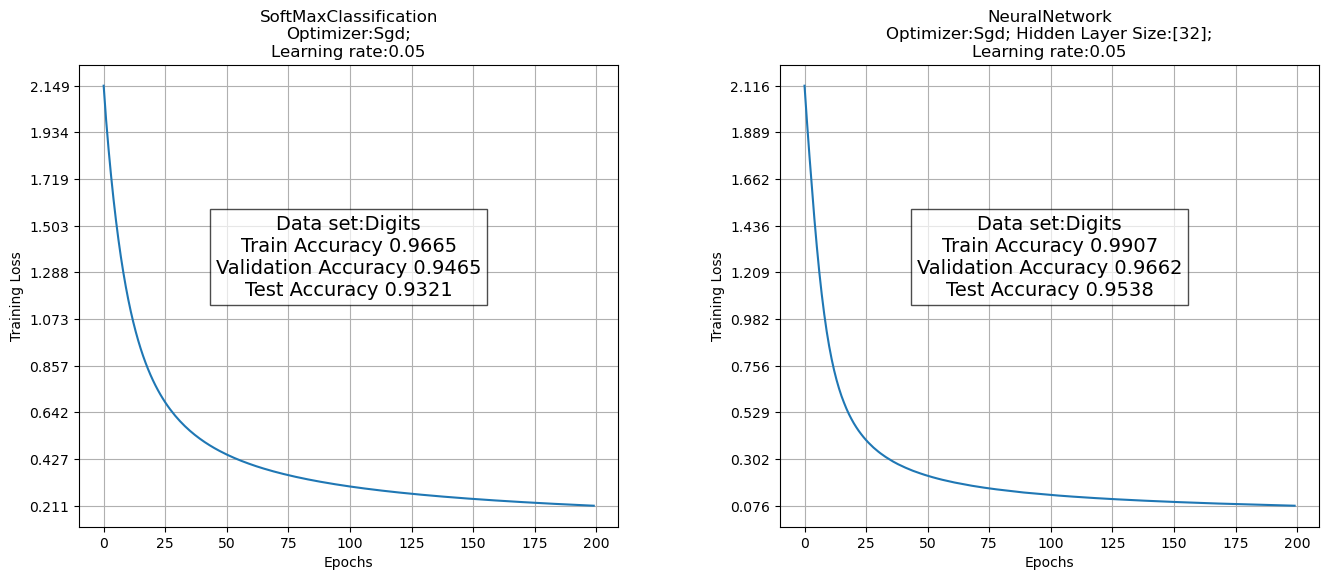

In [21]:
text = f"Data set:{data_name[0]}"
fig, axs = plt.subplots(1, 2,figsize=(16,6),gridspec_kw={"hspace": 0.4, "wspace": 0.3})

ss = SoftMaxClassification()
ss.fit(X_d_train,y_d_train)

val_accuacy = accuracy(ss.predict(X_d_val),y_d_val)
train_accuracy = accuracy(ss.predict(X_d_train),y_d_train)
test_accuacy = accuracy(ss.predict(X_d_test),y_d_test)

text = f"Data set:{data_name[0]}\nTrain Accuracy {train_accuracy:.4f}\nValidation Accuracy {val_accuacy:.4f}\nTest Accuracy {test_accuacy:.4f}"

axs[0].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[0].transAxes,bbox=dict(facecolor='white', alpha=0.7))
ss.plot_loss(ax=axs[0])


nn = NeuralNetwork()
nn.fit(X_d_train,y_d_train)
val_accuacy = accuracy(nn.predict(X_d_val),y_d_val)
train_accuracy = accuracy(nn.predict(X_d_train),y_d_train)
test_accuacy = accuracy(nn.predict(X_d_test),y_d_test)

text = f"Data set:{data_name[0]}\nTrain Accuracy {train_accuracy:.4f}\nValidation Accuracy {val_accuacy:.4f}\nTest Accuracy {test_accuacy:.4f}"


axs[1].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[1].transAxes,bbox=dict(facecolor='white', alpha=0.7))
nn.plot_loss(ax=axs[1])
plt.show()

#### 7.2 Checkpoint policy across datasets
##### Use a simple and consistent checkpoint policy:
- For the two synthetic tasks, you may report the final epoch within your stated training budget
unless you explicitly justify a different choice.
- For the digits benchmark, you must use the best validation-cross-entropy checkpoint within the
allowed epoch budget.

Accuracy mean:0.94250
Loss mean for 5 models:0.21367
95 % Confidence Interval for Accuracy mean:(0.93400,0.95100)
95 % Confidence Interval for Loss mean:(0.21123,0.21611)

Accuracy mean:0.94000
Loss mean for 5 models:0.21868
95 % Confidence Interval for Accuracy mean:(0.93306,0.94694)
95 % Confidence Interval for Loss mean:(0.21484,0.22251)

Accuracy mean:0.94000
Loss mean for 5 models:0.21620
95 % Confidence Interval for Accuracy mean:(0.93306,0.94694)
95 % Confidence Interval for Loss mean:(0.21330,0.21911)



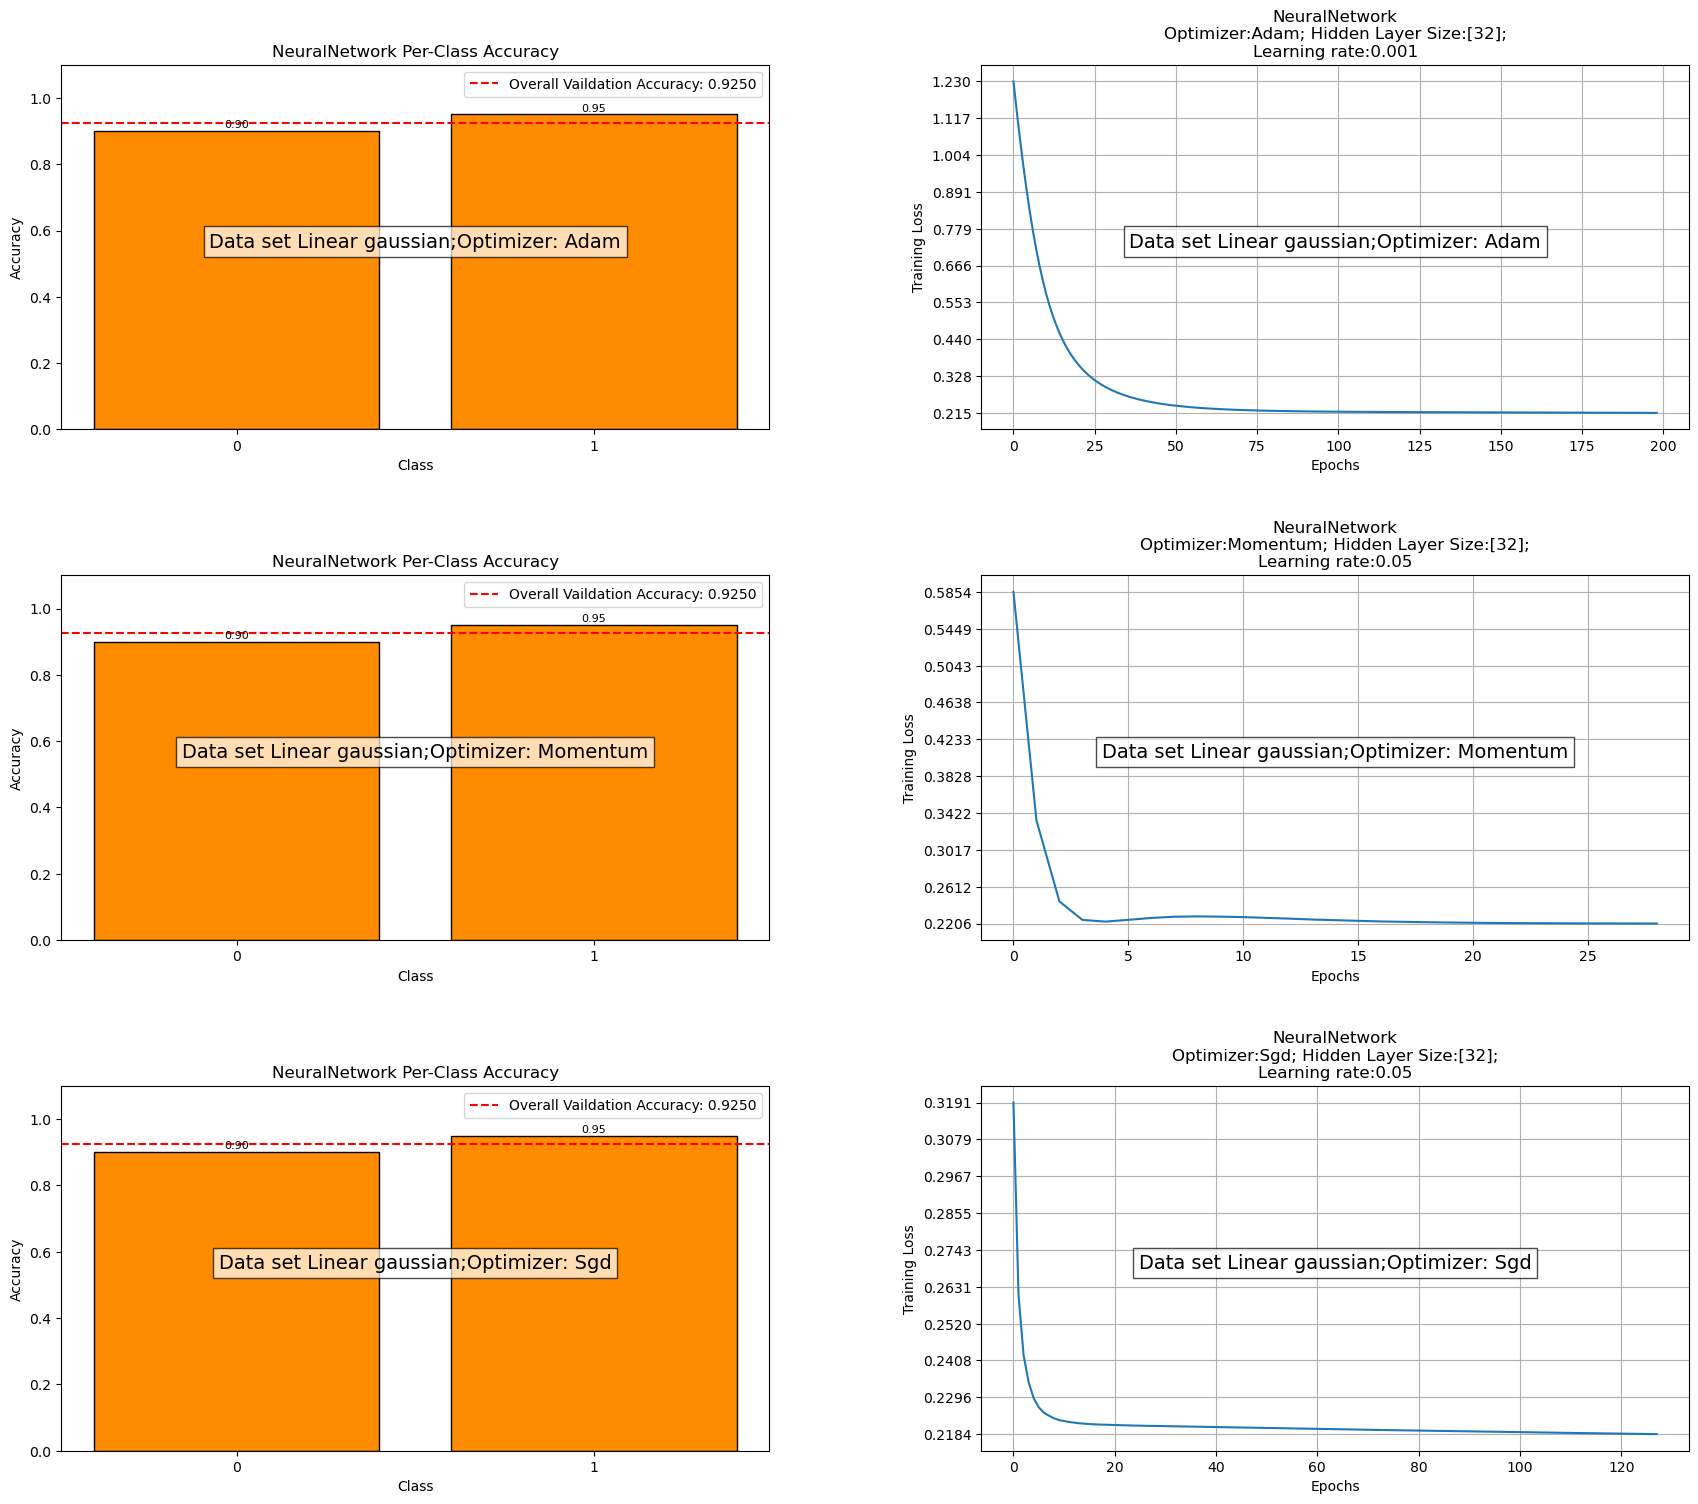

Accuracy mean:0.89000
Loss mean for 5 models:0.25083
95 % Confidence Interval for Accuracy mean:(0.84422,0.93578)
95 % Confidence Interval for Loss mean:(0.20915,0.29250)

Accuracy mean:0.88250
Loss mean for 5 models:0.26312
95 % Confidence Interval for Accuracy mean:(0.87400,0.89100)
95 % Confidence Interval for Loss mean:(0.25171,0.27453)

Accuracy mean:0.88250
Loss mean for 5 models:0.26076
95 % Confidence Interval for Accuracy mean:(0.87400,0.89100)
95 % Confidence Interval for Loss mean:(0.24915,0.27238)



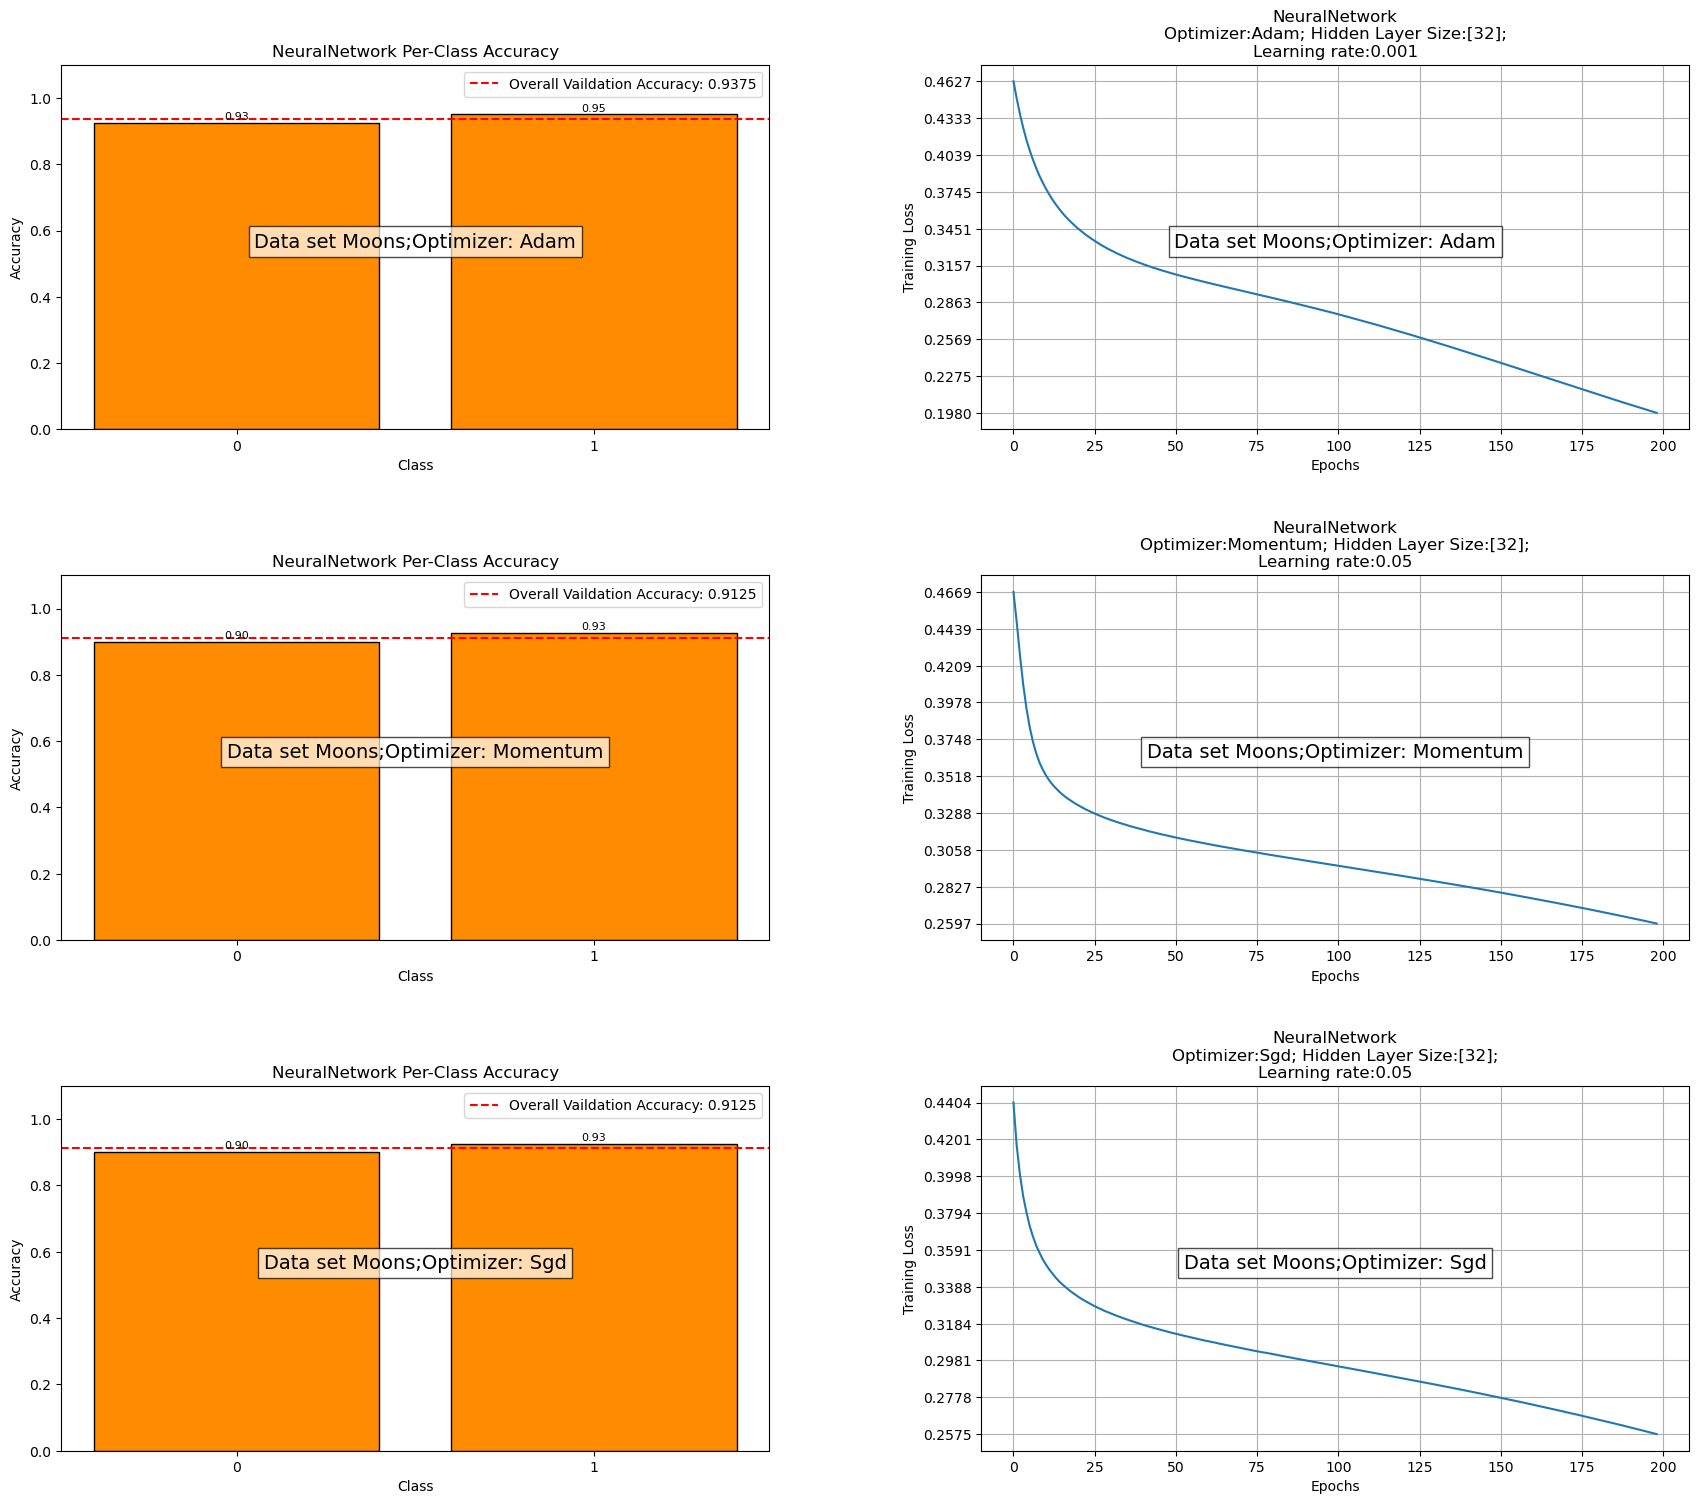

In [22]:
for j in range(1,3):
    fig,axs =  plt.subplots(3,2,figsize=(21,18),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
    for (i,o) in enumerate(["adam","momentum","sgd"]):
        text = f"Data set {data_name[j]};Optimizer: {o.capitalize()}"

        validation_nn = Validation(NeuralNetwork,*data[j],*test_data[j],params={"size":[32],"optimizer":o})
        acc_m,model_nn = validation_nn.fit()
        axs[i,0].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[i,0].transAxes,bbox=dict(facecolor='white', alpha=0.7))

        axs[i,1].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[i,1].transAxes,bbox=dict(facecolor='white', alpha=0.7))
        validation_nn.report(axs[i,0])
        model_nn.plot_loss(axs[i,1])
        print()
    plt.show()

Accuracy mean:0.95489
Loss mean for 5 models:0.03097
95 % Confidence Interval for Accuracy mean:(0.94876,0.96102)
95 % Confidence Interval for Loss mean:(0.03049,0.03144)

Accuracy mean:0.95000
Loss mean for 5 models:0.07551
95 % Confidence Interval for Accuracy mean:(0.94300,0.95700)
95 % Confidence Interval for Loss mean:(0.07452,0.07649)

Accuracy mean:0.95000
Loss mean for 5 models:0.07528
95 % Confidence Interval for Accuracy mean:(0.94342,0.95658)
95 % Confidence Interval for Loss mean:(0.07432,0.07625)



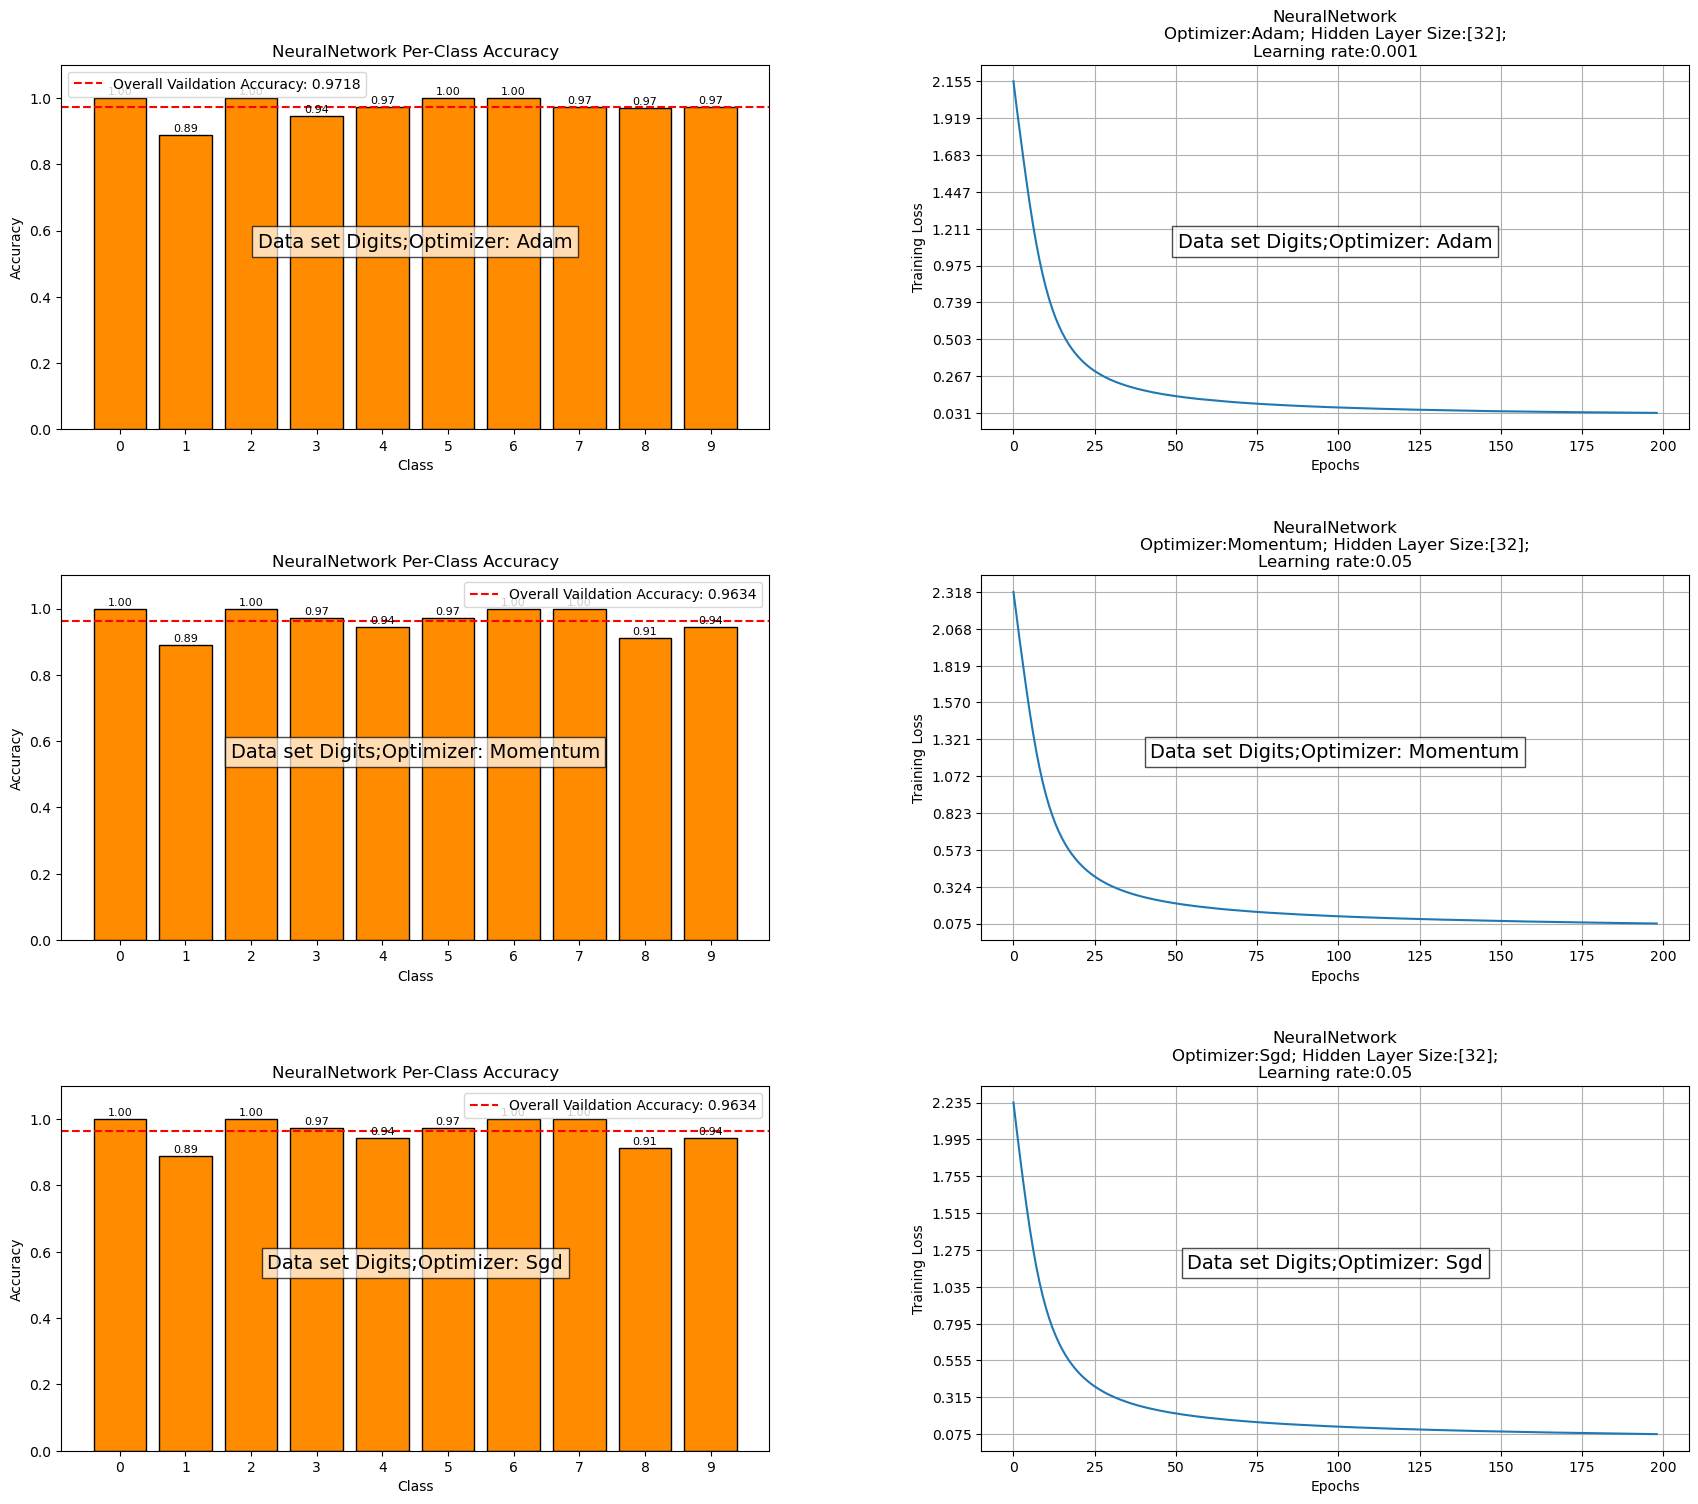

In [23]:
fig,axs =  plt.subplots(3,2,figsize=(21,18),gridspec_kw={"hspace": 0.4, "wspace": 0.3})

for (i,o) in enumerate(["adam","momentum","sgd"]):
    text = f"Data set {data_name[0]};Optimizer: {o.capitalize()}"
    validation_nn = Validation(NeuralNetwork,*data[0],*test_data[0],params={"size":[32],"optimizer":o})
    acc_m,model_nn = validation_nn.fit()
    axs[i,0].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[i,0].transAxes,bbox=dict(facecolor='white', alpha=0.7))
    axs[i,1].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[i,1].transAxes,bbox=dict(facecolor='white', alpha=0.7))
    validation_nn.report(axs[i,0])
    model_nn.plot_loss(axs[i,1])
    print()
plt.show()

### 7.3 Required ablations

1. Capacity ablation on moons. Use hidden widths {2, 8, 32}. Interpret what changes in the learned decision boundary.

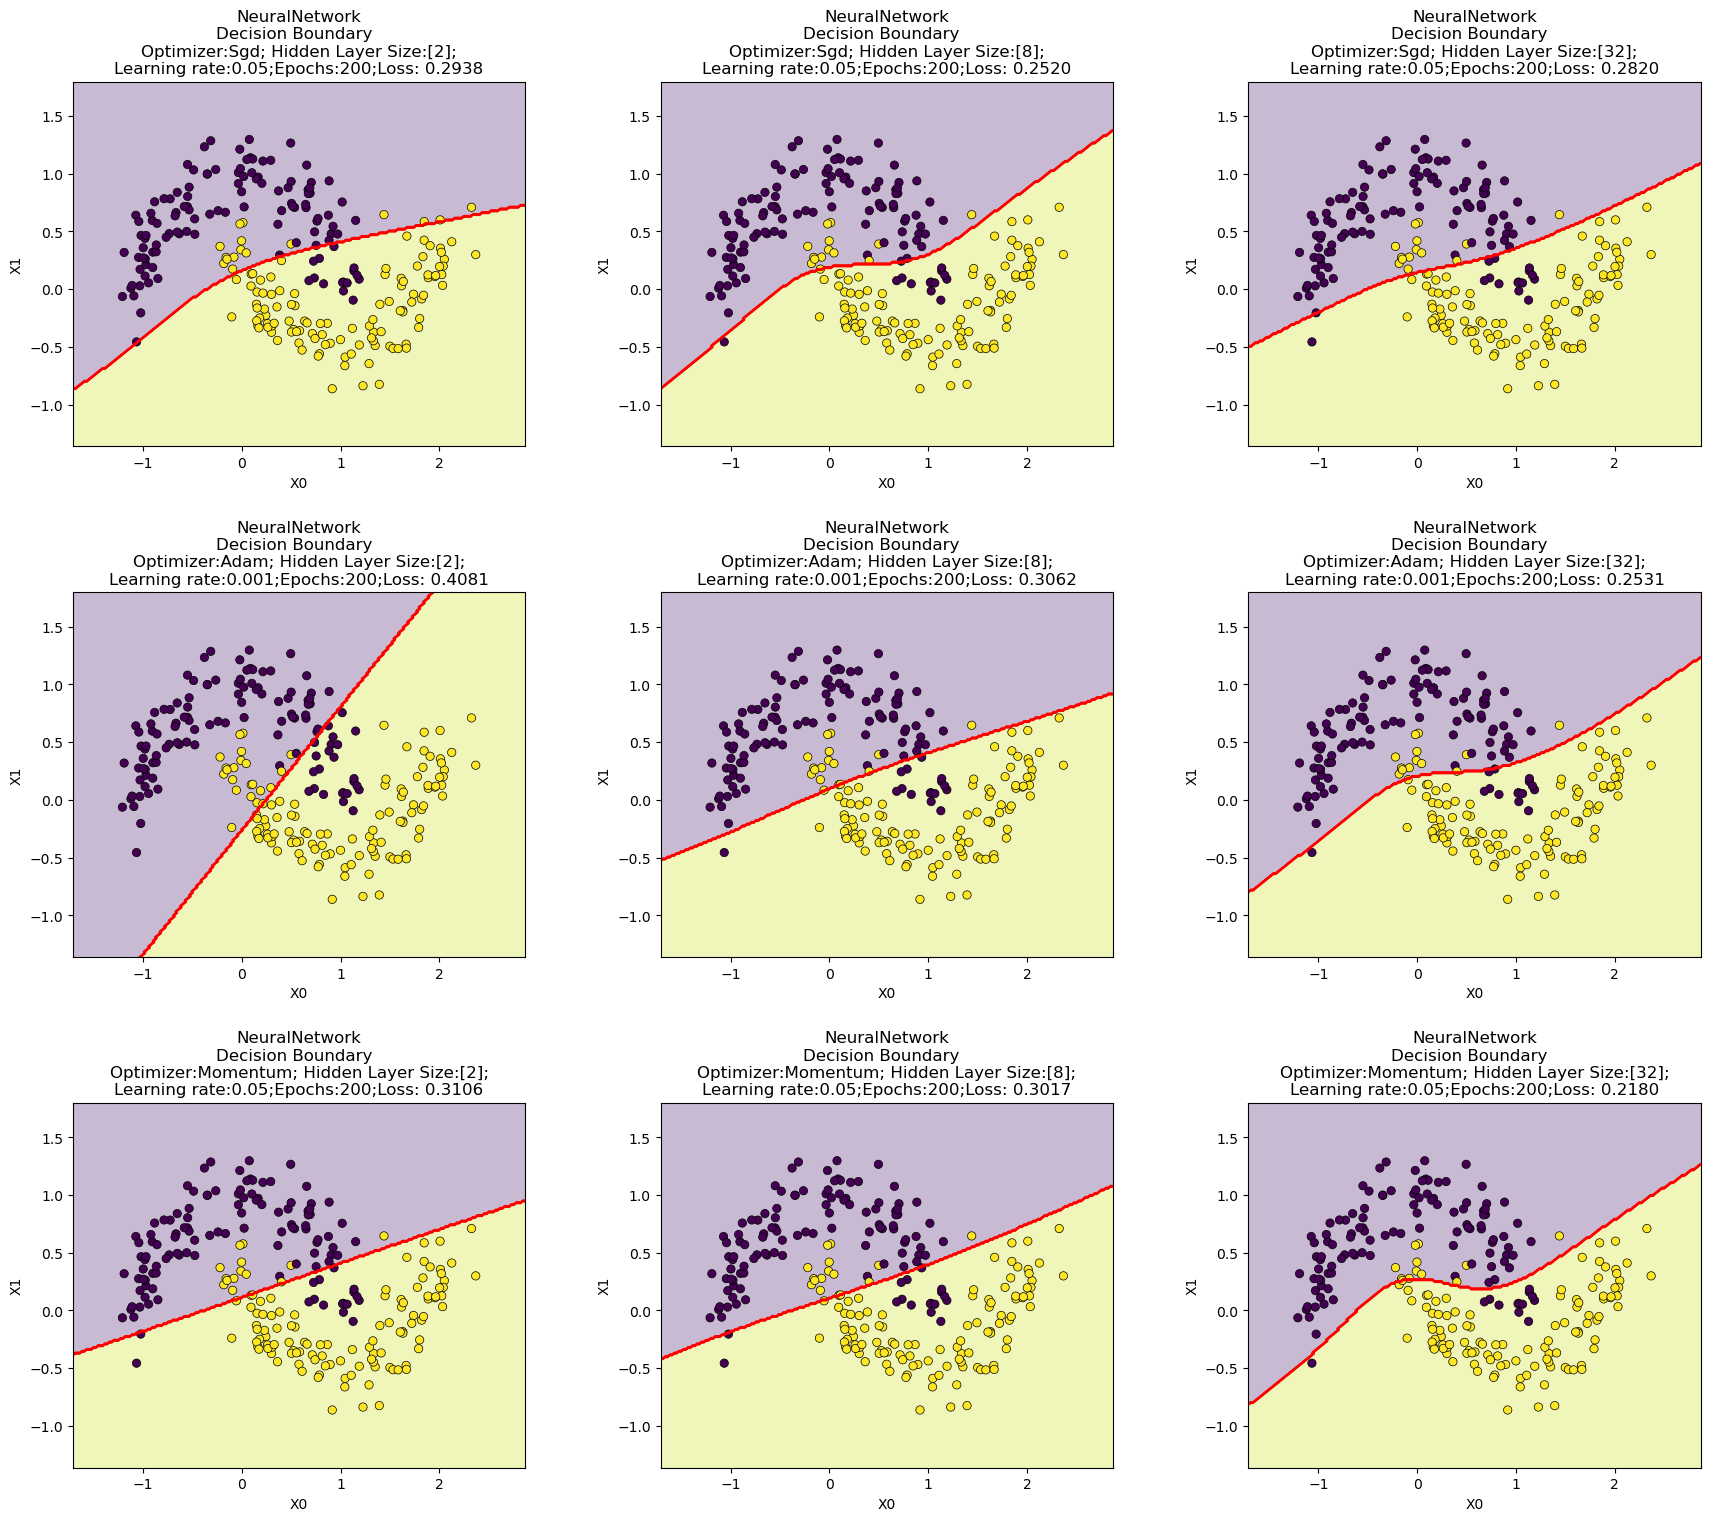

In [24]:
fig, axs = plt.subplots(3, 3,figsize=(21, 18),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
for i,(o,s) in enumerate(itertools.product(["sgd","adam","momentum"],[2,8,32])):
    nn = NeuralNetwork(size=[s],optimizer=o)
    nn.fit(X_m_train,y_m_train)
    ax = axs[i//3,i%3]
    nn.plot_decision_boundary(X_m_train,y_m_train,ax)

2. **Optimizer study on digits.** On the one-hidden-layer neural network with hidden width 32,
compare exactly these optimizers: SGD, Momentum, and Adam, using the default settings
stated in the digits protocol. Softmax regression is not part of this optimizer comparison; it
remains the fixed baseline model. Use the same split, preprocessing, epoch budget, metrics, and
checkpoint rule for all three optimizers. The goal is to compare training behavior under fixed
conditions, not to perform separate hyperparameter tuning for each optimizer.

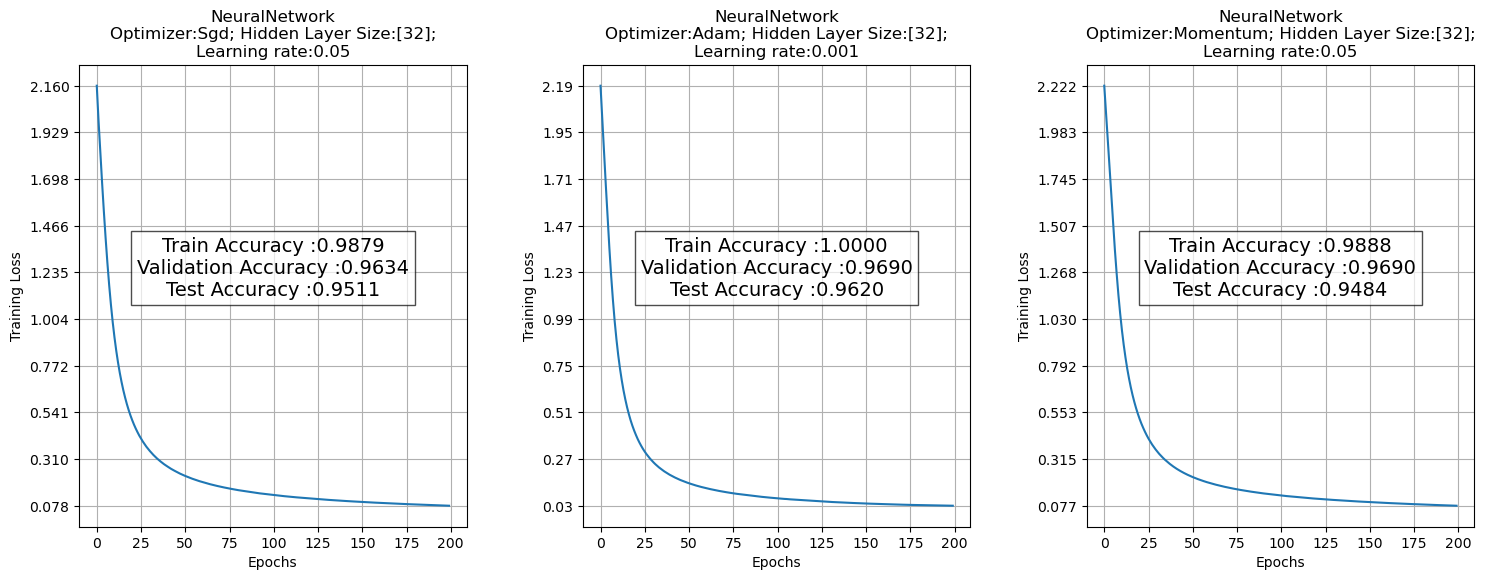

In [25]:
fig, axs = plt.subplots(1, 3,figsize=(18, 6),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
for i,o in enumerate(["sgd","adam","momentum"]):
    nn = NeuralNetwork(optimizer=o)
    nn.fit(X_d_train,y_d_train)
    train_acc = accuracy(nn.predict(X_d_train),y_d_train)
    val_acc = accuracy(nn.predict(X_d_val),y_d_val)
    test_acc = accuracy(nn.predict(X_d_test),y_d_test)
    text = f"Train Accuracy :{train_acc:.4f}\nValidation Accuracy :{val_acc:.4f}\nTest Accuracy :{test_acc:.4f}"
    ax = axs[i]
    ax.text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=ax.transAxes,bbox=dict(facecolor='white', alpha=0.7))
    nn.plot_loss(ax)

3. ***One failure-case analysis.*** This may come from under-capacity, an optimizer behaving poorly,
instability, or visible overfitting. You must explain why it failed, not merely show that it failed

#### Overfitting Due to Small Training Data and Many Epochs

When the size of the training dataset is small, and the number of training epochs is relatively large compared to the amount of data, the model is more likely to suffer from **overfitting**.

**Overfitting** occurs because the model is exposed to the same limited set of training examples many times during training. Instead of learning general patterns that can be applied to unseen data, the model begins to **memorize** the training data, including noise and minor fluctuations that are not representative of the true underlying distribution.

As a result:

- The model achieves **very high performance on the training set**  
- But performs **poorly on validation or test data**

This happens because the model fails to generalize beyond the specific examples it has seen.

##### Why This Happens

- **Limited training data** → does not capture the full variability of the problem  
- **Too many epochs** → repeated exposure to the same samples  
- **High model capacity (many parameters)** → makes memorization easier  

Together, these factors encourage the model to fit the training data too closely.

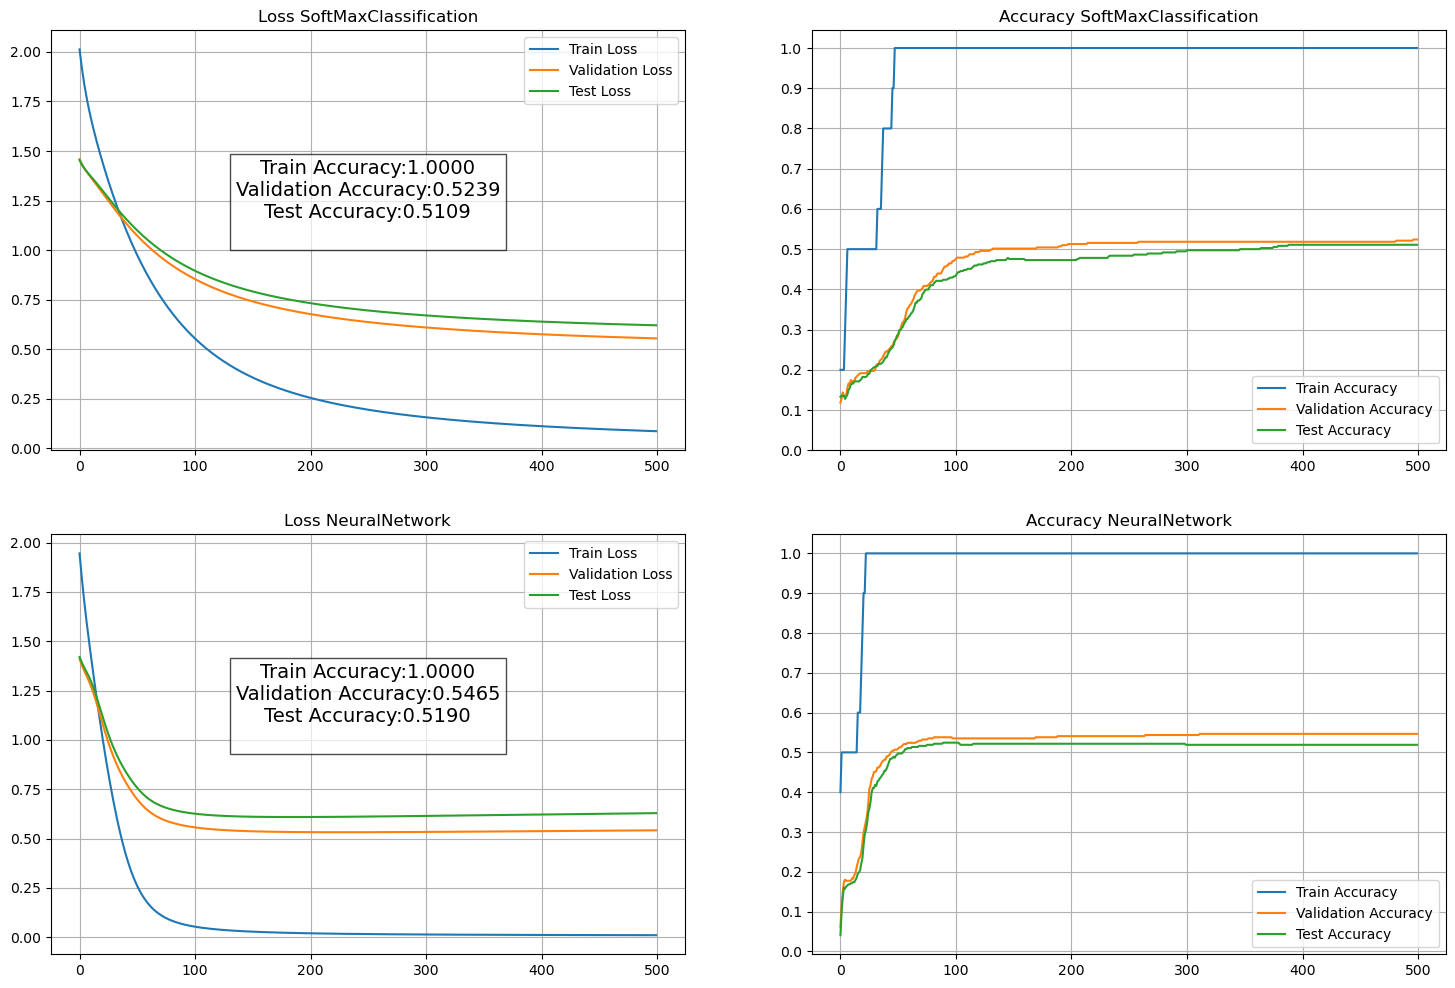

In [26]:
fig,axs = plt.subplots(2,2,figsize=(18,12))
ss = SoftMaxClassification()
Validation.test_model(ss,X_d_train[:10],y_d_train[:10],X_d_val,y_d_val,X_d_test,y_d_test,epochs=500,axes = axs[0])

nn = NeuralNetwork(optimizer="adam",learning_rate=0.001,size=[128])
Validation.test_model(nn,X_d_train[:10],y_d_train[:10],X_d_val,y_d_val,X_d_test,y_d_test,epochs=500,axes = axs[1])
plt.show()

### Impact of Biased Data and High Learning Rate with Adam Optimizer

When the training dataset is **biased**, meaning it does not accurately reflect the full diversity of real-world data, the model is more likely to **overfit**. Overfitting occurs because the model learns patterns that appear in the biased subset rather than general patterns that apply to unseen data. As a result, the model may perform well on the training set but fail on new, unbiased data.

##### Why Biased Data Leads to Overfitting

- The model sees a **skewed distribution** of features repeatedly.  
- It **memorizes patterns** that are frequent in the biased subset.  
- On unbiased or diverse data, performance drops, because the model has not learned the true underlying relationships.


##### High Learning Rate and Adam Optimizer Instability

The **Adam optimizer** combines momentum and adaptive learning rates to accelerate convergence and stabilize training. However, if the **base learning rate is too high**:

- Adam’s adaptive step sizes can still be **too large**, causing updates to overshoot minima.  
- Training can **oscillate** or even **diverge**, with loss fluctuating rather than decreasing smoothly.  
- Gradients may spike intermittently, making optimization unstable, especially on biased or noisy data.

Even though Adam is generally more stable than standard SGD, a high learning rate can still lead to:

- **Unstable convergence**  
- **Oscillatory loss**  
- **Difficulty reaching a proper minimum**

#### Combined Effect of Biased Data and High Learning Rate

When biased data is used with Adam and a high learning rate:

- The model tends to **overfit the biased patterns** in the training set.  
- Training dynamics can **oscillate**, slowing convergence and reducing generalization.  
- This combination makes it harder for Adam to take advantage of its adaptive properties.


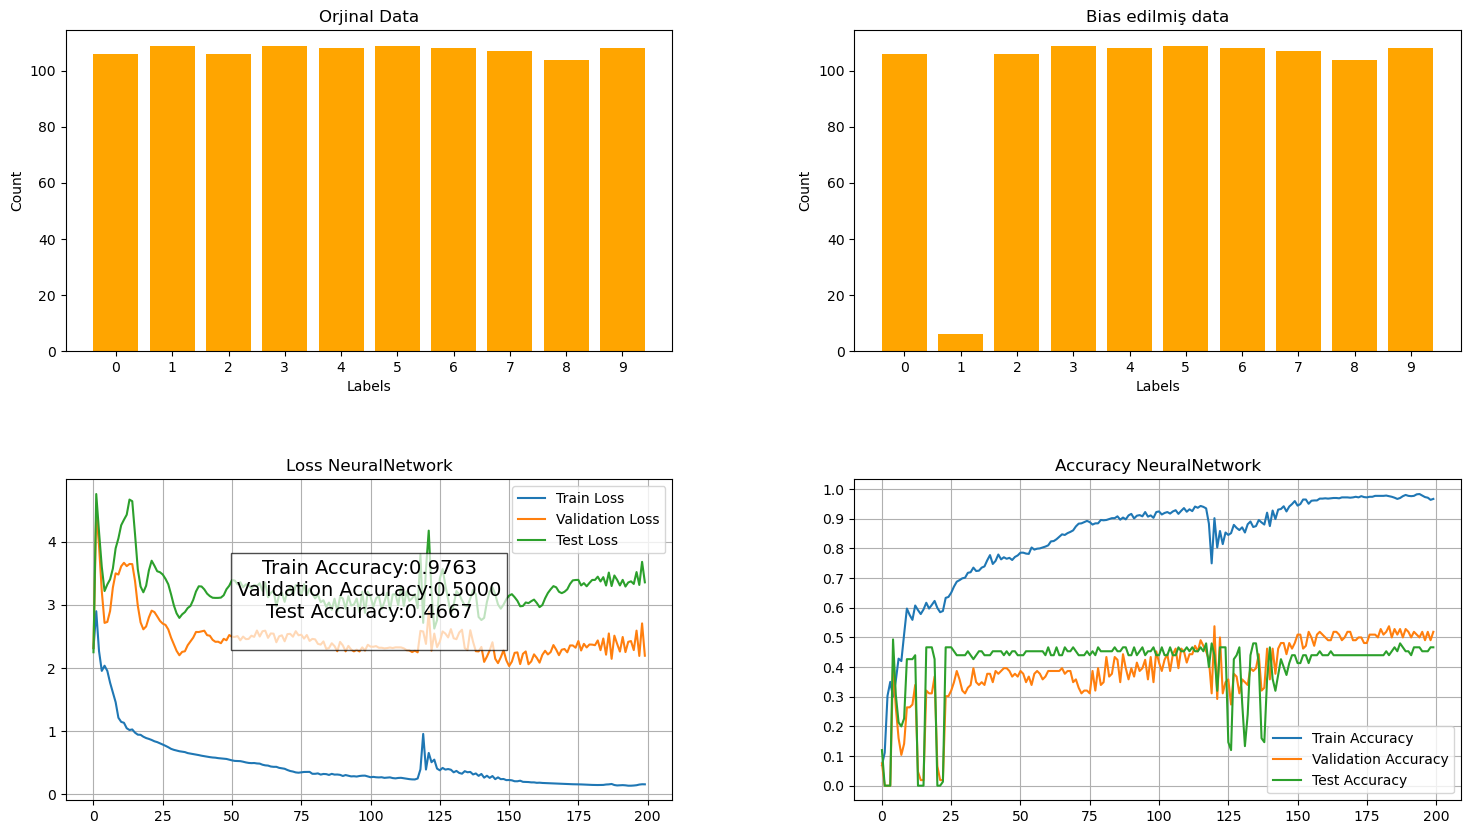

In [36]:
fig, axs = plt.subplots(2, 2,figsize=(18, 10),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
idxs = make_bias(y_d_train,1)
plot_hist(y_d_train,idxs,axs[0])
nn = NeuralNetwork(optimizer="adam",learning_rate=0.3,size=[8])
t_idxs = np.where((y_d_test==1)|(y_d_test==3))
v_idxs = np.where((y_d_val==1)|(y_d_val==3)|(y_d_val==8))
Validation.test_model(nn,X_d_train[idxs],y_d_train[idxs],X_d_val[v_idxs],y_d_val[v_idxs],X_d_test[t_idxs],y_d_test[t_idxs],axes=axs[1])
plt.show()

## 7.4 Repeated-seed statistics
For the digits benchmark, model selection and final reporting must follow this exact protocol:
1. Use the training set to fit parameters.
2. Use the validation set only to choose settings and select the best epoch.
3. Fix one final selected configuration for softmax regression and one for the neural network using
validation evidence only.
4. For each selected configuration, run five seeds.
5. For each seed, evaluate the test set exactly once after the configuration and best epoch have
been selected.


- mean test accuracy over 5 seeds,
- mean test cross-entropy over 5 seeds,
- a 95% confidence interval for each mean,
- a short interpretation of what the variability does and does not justify.
With five seeds, an acceptable 95% confidence interval for the sample mean is
$\bar{x} \pm 2.776 \cdot \frac{s}{\sqrt{5}}$
where x̄ is the sample mean and s is the sample standard deviation. If you use a different correct
method, state it clearly.

--- Statistics for 5 Seeds ---
Accuracy mean:0.93641
Loss mean for 5 models:0.21191
95 % Confidence Interval for Accuracy mean:(0.93456,0.93826)
95 % Confidence Interval for Loss mean:(0.20992,0.21391)


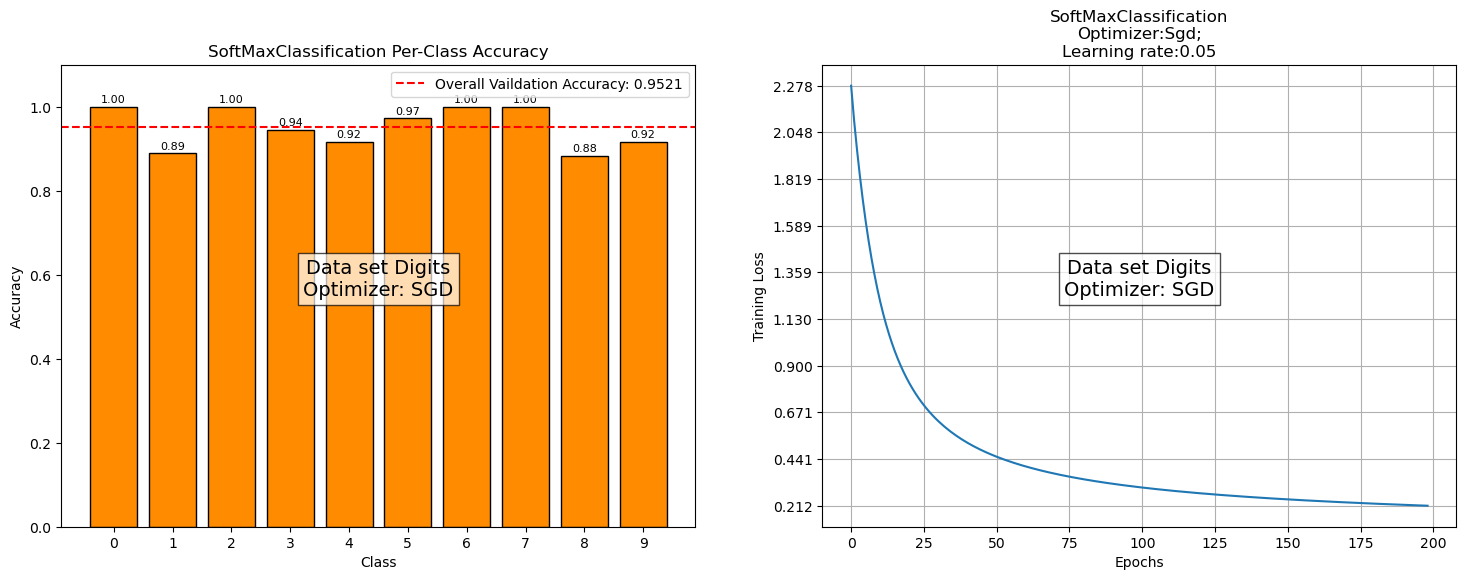

In [28]:
fig,axs =  plt.subplots(1,2,figsize=(18,6))
print(f"--- Statistics for 5 Seeds ---")
text = f"Data set {data_name[0]}\nOptimizer: SGD"
validation_s = Validation(SoftMaxClassification,*data[0],*test_data[0])
acc,model_s = validation_s.fit()
validation_s.report(axs[0])
model_s.plot_loss(axs[1])
axs[0].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[0].transAxes,bbox=dict(facecolor='white', alpha=0.7))
axs[1].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[1].transAxes,bbox=dict(facecolor='white', alpha=0.7))
plt.show()

--- Statistics for 5 Seeds ---
Accuracy mean:0.95489
Loss mean for 5 models:0.03097
95 % Confidence Interval for Accuracy mean:(0.94876,0.96102)
95 % Confidence Interval for Loss mean:(0.03049,0.03144)

Accuracy mean:0.95000
Loss mean for 5 models:0.07551
95 % Confidence Interval for Accuracy mean:(0.94300,0.95700)
95 % Confidence Interval for Loss mean:(0.07452,0.07649)

Accuracy mean:0.95000
Loss mean for 5 models:0.07528
95 % Confidence Interval for Accuracy mean:(0.94342,0.95658)
95 % Confidence Interval for Loss mean:(0.07432,0.07625)



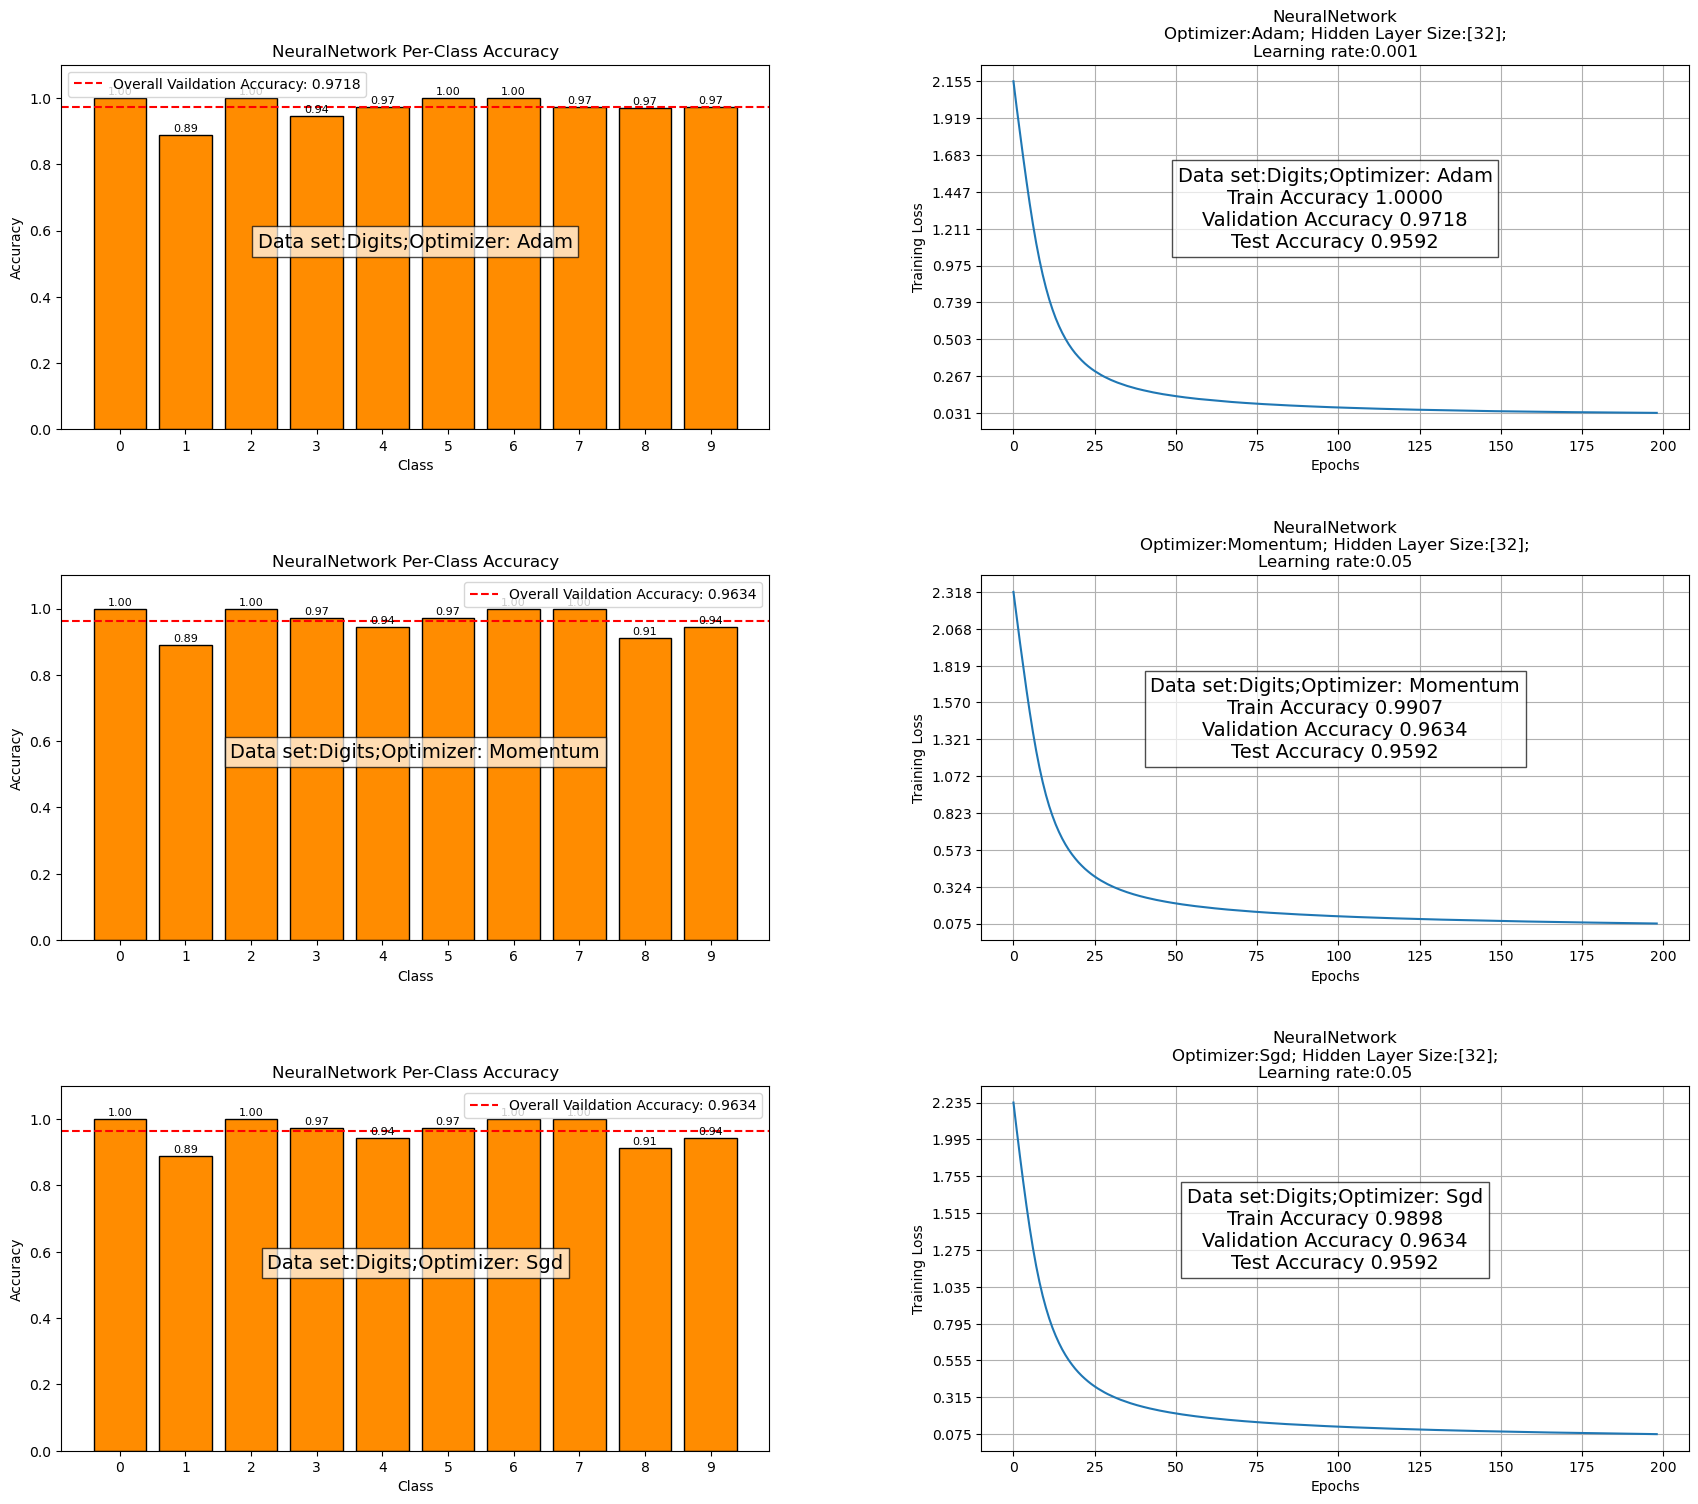

Accuracy mean:0.94250
Loss mean for 5 models:0.21860
95 % Confidence Interval for Accuracy mean:(0.93400,0.95100)
95 % Confidence Interval for Loss mean:(0.21495,0.22226)

Accuracy mean:0.94000
Loss mean for 5 models:0.21855
95 % Confidence Interval for Accuracy mean:(0.93306,0.94694)
95 % Confidence Interval for Loss mean:(0.21476,0.22234)

Accuracy mean:0.94000
Loss mean for 5 models:0.21815
95 % Confidence Interval for Accuracy mean:(0.93306,0.94694)
95 % Confidence Interval for Loss mean:(0.21459,0.22170)



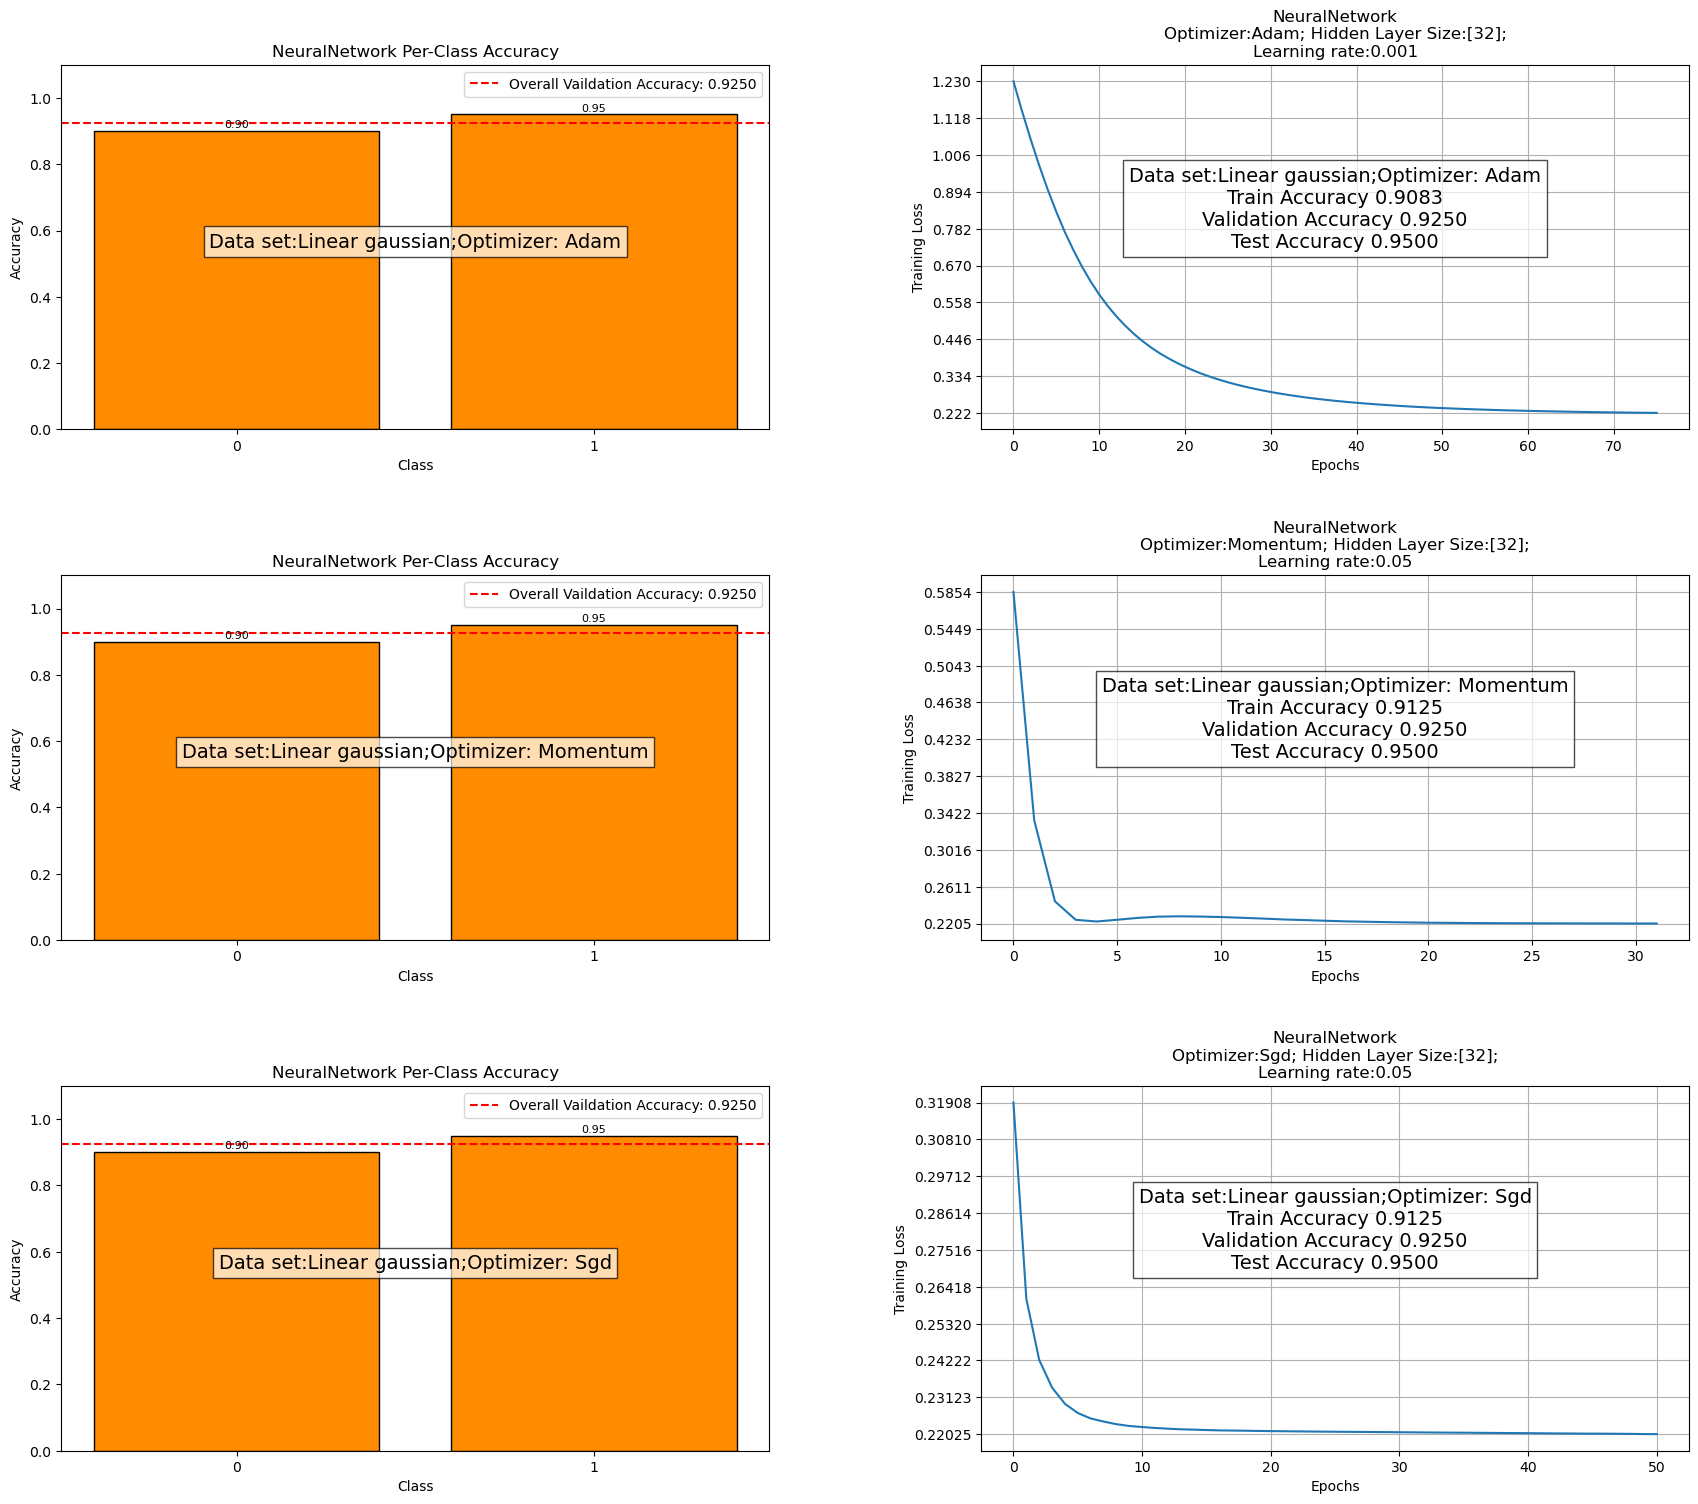

Accuracy mean:0.89000
Loss mean for 5 models:0.25083
95 % Confidence Interval for Accuracy mean:(0.84422,0.93578)
95 % Confidence Interval for Loss mean:(0.20915,0.29250)

Accuracy mean:0.88250
Loss mean for 5 models:0.26312
95 % Confidence Interval for Accuracy mean:(0.87400,0.89100)
95 % Confidence Interval for Loss mean:(0.25171,0.27453)

Accuracy mean:0.88250
Loss mean for 5 models:0.26076
95 % Confidence Interval for Accuracy mean:(0.87400,0.89100)
95 % Confidence Interval for Loss mean:(0.24915,0.27238)



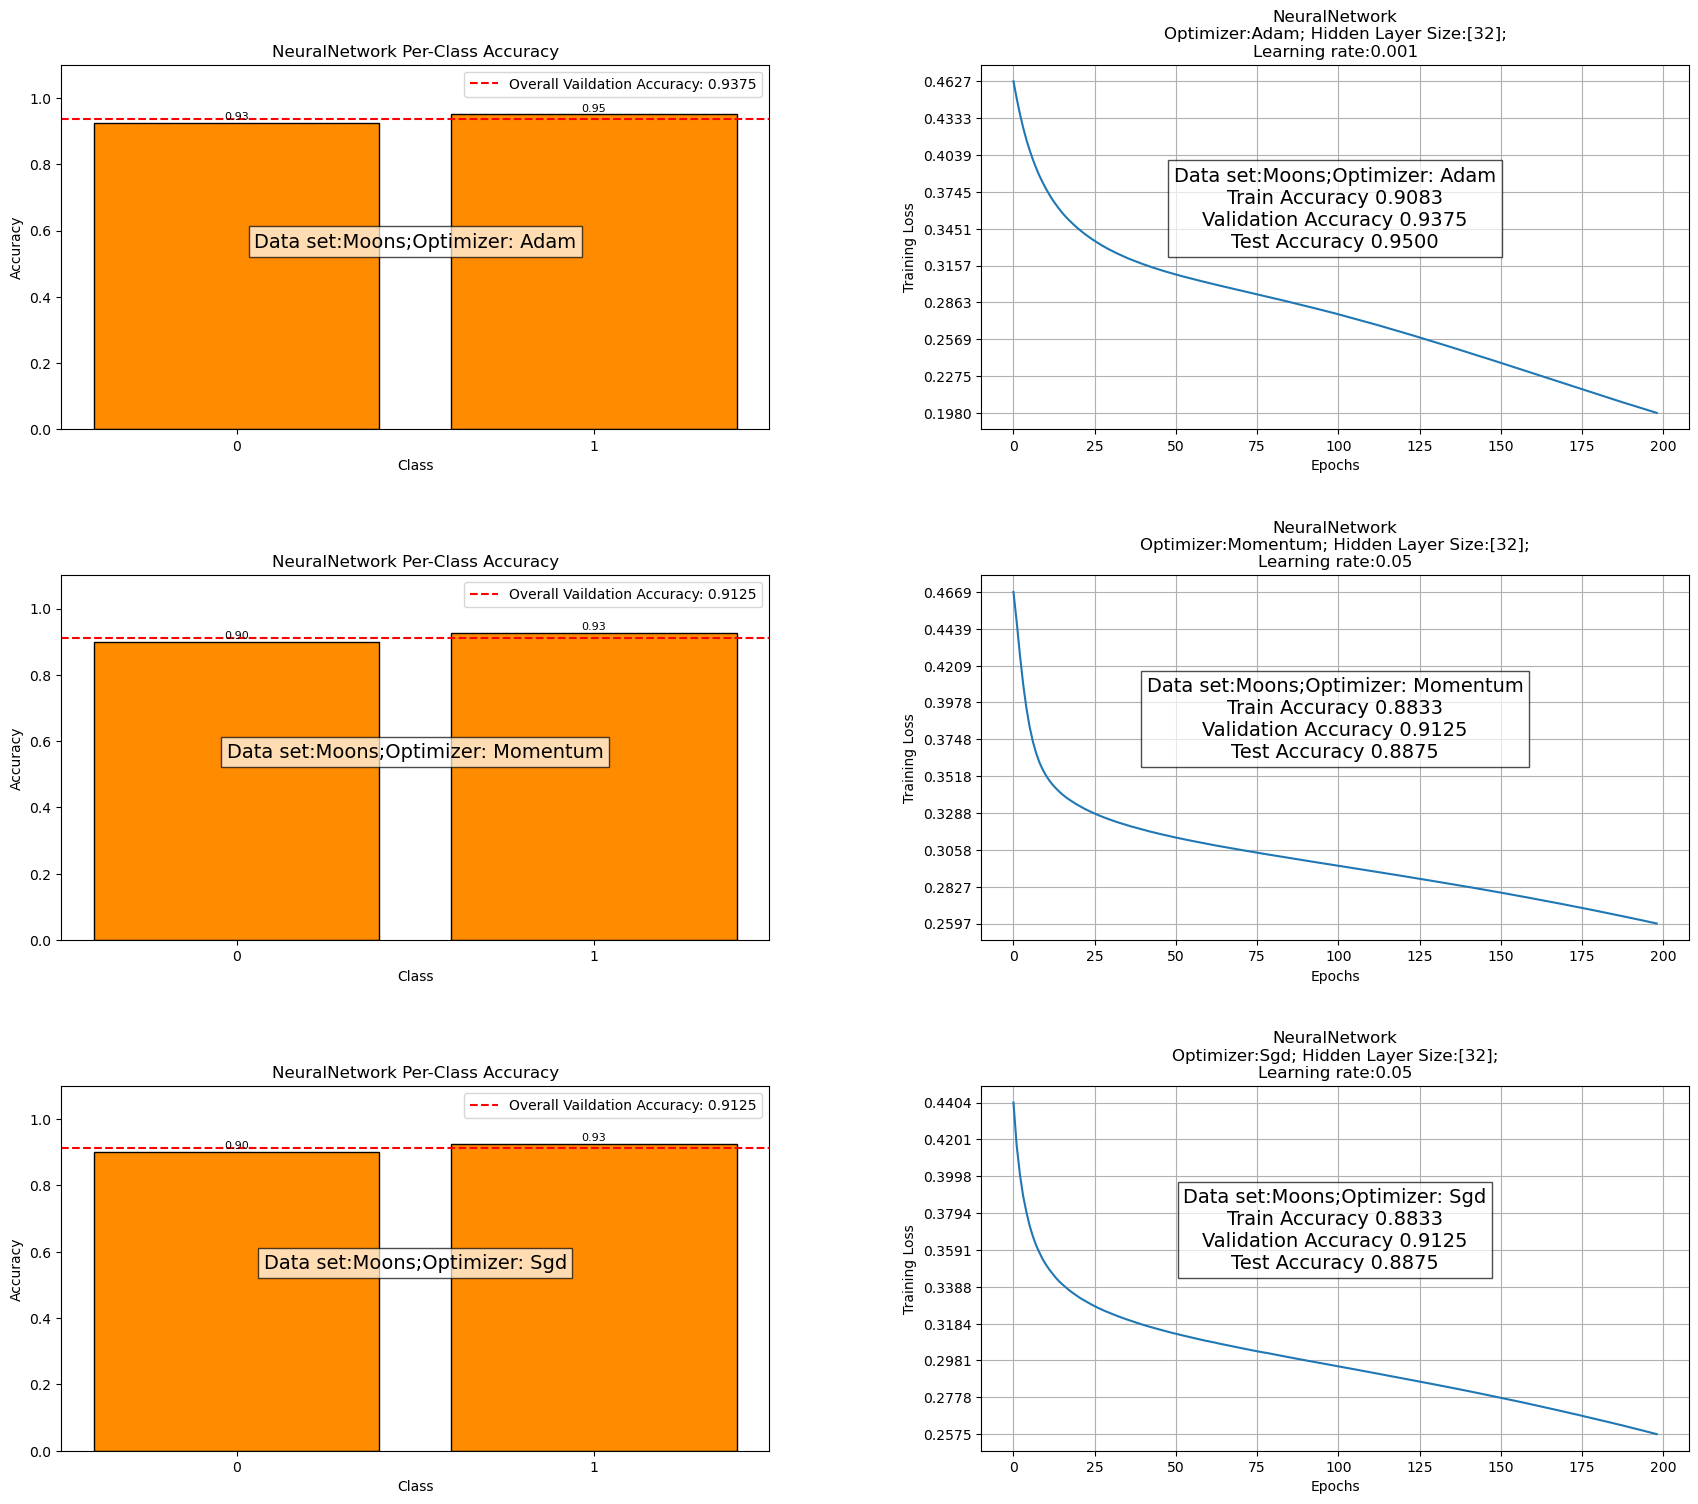

In [29]:

print(f"--- Statistics for 5 Seeds ---")
for j in range(3):
    fig,axs =  plt.subplots(3,2,figsize=(21,18),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
    for (i,o) in enumerate(["adam","momentum","sgd"]):
        text = f"Data set:{data_name[j]};Optimizer: {o.capitalize()}"
        validation_nn = Validation(NeuralNetwork,*data[j],*test_data[j],params={"size":[32],"optimizer":o})
        acc_m,model_nn = validation_nn.fit()
        axs[i,0].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[i,0].transAxes,bbox=dict(facecolor='white', alpha=0.7))
        
        val_accuacy = accuracy(model_nn.predict(data[j][2]),data[j][3])
        train_accuracy = accuracy(model_nn.predict(data[j][0]),data[j][1])
        test_accuacy = accuracy(model_nn.predict(test_data[j][0]),test_data[j][1])
        
        text = f"Data set:{data_name[j]};Optimizer: {o.capitalize()}\nTrain Accuracy {train_accuracy:.4f}\nValidation Accuracy {val_accuacy:.4f}\nTest Accuracy {test_accuacy:.4f}"
        axs[i,1].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[i,1].transAxes,bbox=dict(facecolor='white', alpha=0.7))
        validation_nn.report(axs[i,0])
        model_nn.plot_loss(axs[i,1])
        print()
    plt.show()

### 8.1 Track A: PCA/SVD and input geometry
This is a focused analysis, not a second large experiment grid. Its purpose is to study input
geometry and dimensional compression before classification, and to compare linear structure in the
input to what nonlinear representation learning may add.
Required work:
- one scree plot,
- one 2D PCA visualization of the digits data,
- one small softmax comparison at fixed PCA dimensions m ∈ {10, 20, 40},
- a brief interpretation tied back to the main project question.
Use the digits data in starter_pack/data/digits_data.npz for this track.


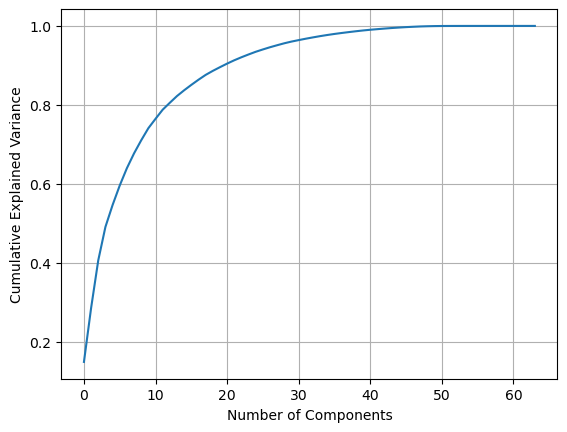

In [30]:
def plot_scree(X_d_train):
    X_centered = X_d_train - np.mean(X_d_train,axis=0,keepdims=True)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    explained_variance = (S**2) / (X_centered.shape[0] - 1)
    total_var = np.sum(explained_variance)
    var_ratio = explained_variance / total_var

    plt.plot(np.cumsum(var_ratio))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid()
    plt.show()
plot_scree(X_d_train)

In [31]:
def pca_dimensions(X_train):
    X_mean = np.mean(X_train,axis=0,keepdims=True)
    X_centered = X_train - X_mean
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return X_mean,X_centered,Vt

In [32]:
X_mean,X_centered,Vt = pca_dimensions(X_d_train)

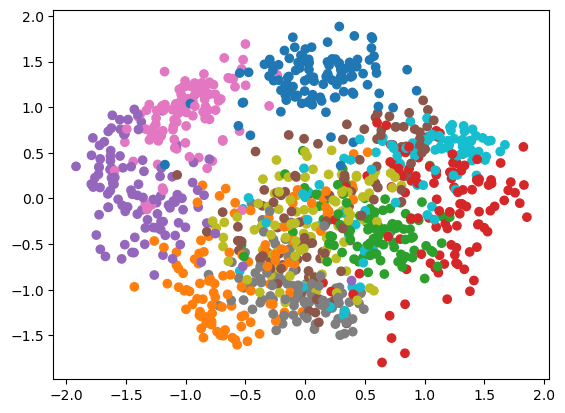

In [33]:
X_2d = X_centered @ Vt[:2].T
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_d_train, cmap='tab10')
plt.show()

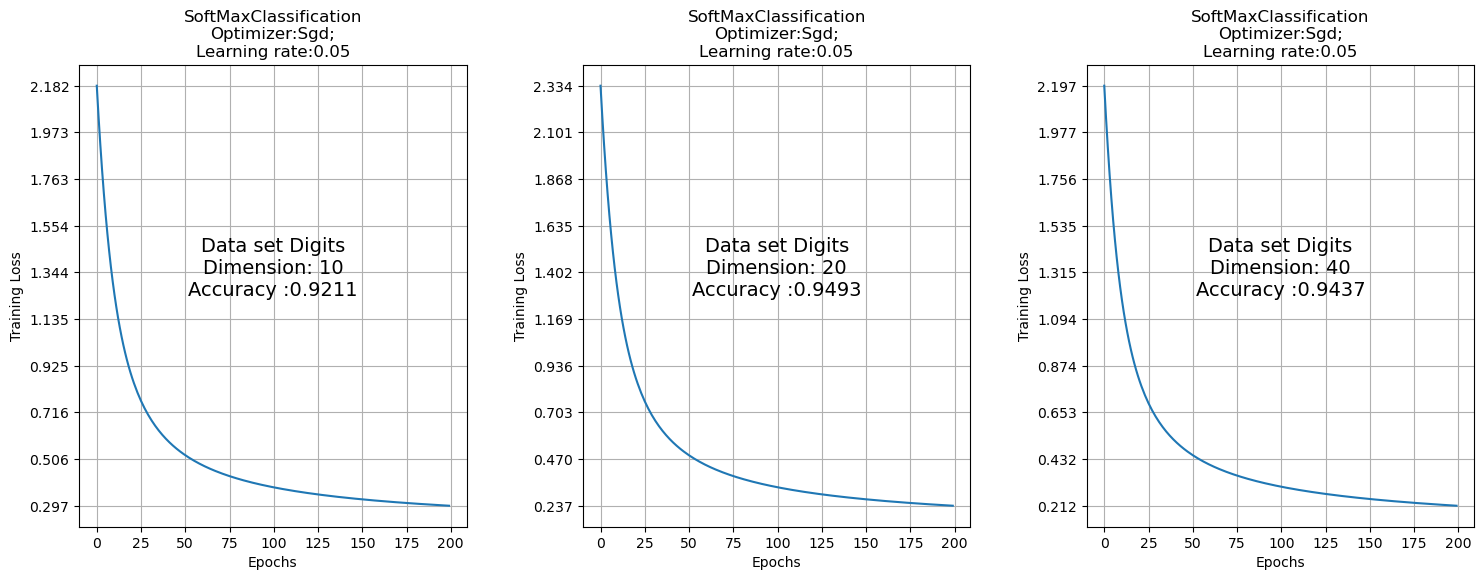

In [34]:
X_d_val_centered = X_d_val - X_mean
fig, axs = plt.subplots(1, 3,figsize=(18, 6),gridspec_kw={"hspace": 0.4, "wspace": 0.3})
for i,d in enumerate([10,20,40]):
    X_d_t = X_centered @ Vt[:d].T 
    X_d_v = X_d_val_centered @ Vt[:d].T
    model_pca = SoftMaxClassification()
    model_pca.fit(X_d_t,y_d_train)
    acc = accuracy(model_pca.predict(X_d_v),y_d_val)
    text = f"Data set {data_name[0]}\nDimension: {d}\nAccuracy :{acc:.4f}"
    axs[i].text(0.5,0.5,text,color="black",fontsize=14,ha="center",transform=axs[i].transAxes)
    model_pca.plot_loss(axs[i])
plt.show()
    